# Container Image Vulnerability Scanners: Analysis of Results

This notebook produces every figure and table of the analysis from frozen scan data (July 2026) stored in `results/`.

Figures are saved to `figures/<lang>/` as vector PDF.
Run twice to generate both language variants:

```bash
FIG_LANG=en jupyter nbconvert --execute evaluation_analysis.ipynb
FIG_LANG=pl jupyter nbconvert --execute evaluation_analysis.ipynb
```

In [1]:
import os, sys, itertools, warnings
from collections import Counter

sys.path.insert(0, 'analysis')
# --- bilingual figure labels (inline) : English string is the key, PL below ---
LANG = os.environ.get('FIG_LANG', 'en').lower()
_PL = {
    '% of OS-layer findings': '% znalezisk warstwy systemowej',
    '% of application-layer findings': '% znalezisk warstwy aplikacyjnej',
    '% of findings retained vs the direct scan': '% wykryć zachowanych względem skanu bezpośredniego',
    'Application layer': 'Warstwa aplikacyjna',
    'CVE count': 'liczba CVE',
    'CVEs in the intersection': 'CVE w części wspólnej',
    'CVEs in total': 'CVE łącznie',
    'CVSS spread across the 4 scanners (max - min)': 'Rozstęp CVSS między 4 skanerami (max − min)',
    'Application-layer components (Java)': 'Komponenty warstwy aplikacyjnej (Java)',
    'System-layer components (RPM/apk/deb)': 'Komponenty warstwy systemowej (RPM/apk/deb)',
    'Critical': 'Krytyczna',
    'FP: Red Hat "not affected"': 'FP: Red Hat „not affected”',
    'FP: already patched': 'FP: już naprawiona',
    'High': 'Wysoka',
    'Image size [MB]': 'Rozmiar obrazu [MB]',
    'JVM image (JIB-jvm)': 'obraz JVM (JIB-jvm)',
    'Low': 'Niska',
    'Medium': 'Średnia',
    'Native images (GraalVM)': 'Obrazy natywne (GraalVM)',
    'OS': 'system',
    'OS layer': 'Warstwa systemowa',
    'OS layer (RPM)': 'warstwa systemowa (RPM)',
    'Unique CVEs (Grype, direct scan)': 'Liczba unikalnych CVE (Grype, skan bezpośredni)',
    'Unique CVEs (union of 4 scanners, direct scan)': 'Unikalne CVE (unia 4 skanerów, skan bezpośredni)',
    'Unknown': 'Nieznana',
    'application (Java)': 'aplikacja (Java)',
    'application layer (Java)': 'warstwa aplikacyjna (Java)',
    'injected (build/base)': 'wstrzyknięte (build/baza)',
    'n/a': 'n.d.',
    'native image + embedded SBOM': 'obraz natywny + wbudowany SBOM',
    'real, fix available': 'realna, jest poprawka',
    'real, no fix': 'realna, brak poprawki',
    'share of reported findings': 'skład zgłoszeń [%]',
    'recall: % of confirmed CVEs': 'wykrywalność [% potwierdzonych CVE]',
    'detected (TP)': 'wykryte (TP)',
    'false positive (FP)': 'fałszywie dodatnie (FP)',
    'missed (FN)': 'pominięte (FN)',
    'undecidable': 'nierozstrzygnięte',
}
_missing = set()


def T(s):
    """English in, target language out. Unknown string -> English + noted in report()."""
    if LANG == 'en':
        return s
    hit = _PL.get(s)
    if hit is None:
        _missing.add(s)
        return s
    return hit


def report():
    """Summary for the notebook's last cell: flags any untranslated string on a PL run."""
    if LANG == 'en':
        return 'FIG_LANG=en - figures written to figures/en/'
    if not _missing:
        return 'FIG_LANG=pl - all strings translated, figures written to figures/pl/'
    return f'FIG_LANG=pl - {len(_missing)} UNTRANSLATED: {sorted(_missing)}'
from scanlib import (SCANNERS, SEV_ORDER, IMAGES, JVM_IMAGES, IMAGES_ORDER, PREFIX, GROUND_TRUTH,
                     load, parse_trivy, parse_grype, parse_snyk, parse_scout, load_all, load_sbom_cdx)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from upsetplot import UpSet, from_contents

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220)

# --- Palette ---
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE = '#e1e0d9', '#c3c2b7'
SCANNER_C = {'Trivy': '#2a78d6', 'Grype': '#1baf7a', 'Snyk': '#eda100', 'Docker Scout': '#008300'}
BLUES = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', BLUES)
SEV_C = {'CRITICAL': '#8f1d1d', 'HIGH': '#d03b3b', 'MEDIUM': '#e57e7d',
         'LOW': '#f4c1c0', 'UNKNOWN': '#d9d8d2'}
SEV_LBL = {s: T(s.capitalize()) for s in SEV_ORDER}

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'text.color': INK, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.edgecolor': BASELINE, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    out = os.path.join(FIG_DIR, LANG)
    os.makedirs(out, exist_ok=True)
    fig.savefig(os.path.join(out, name + '.pdf'), bbox_inches='tight',
                metadata={'CreationDate': None})

## Data loading

Parse all scanner reports into a single DataFrame.

In [2]:
df, status = load_all('results')
cdx_df, cdx_status = load_sbom_cdx('results')   # CycloneDX control series (16 runs), parsed once and reused
direct_all = df[df.input == 'direct']  # raw (pre-CVE-filter) direct scans, used by the identifier section below


def artifact_id(package):
    package = str(package)
    for separator in ('/', ':'):
        if separator in package:
            package = package.split(separator)[-1]
    return package.lower()


print(f'Loaded {len(df)} deduped findings  |  images: {df.image.nunique()}  |  main-matrix scans: {len(status)}')
print(f'CycloneDX control series: {len(cdx_df)} findings  |  scans: {len(cdx_status)}')

Loaded 17720 deduped findings  |  images: 9  |  main-matrix scans: 144
CycloneDX control series: 2251 findings  |  scans: 16


### Scan completeness

The 160-run budget is 144 main-matrix scans plus a 16-run CycloneDX control series
(2 images x 2 generators x 4 scanners). The cell below checks both. Every scan
completed except Snyk in SBOM mode: **13 Snyk SBOM runs fail** (11 on the SPDX main
matrix, 2 on the CycloneDX control), all deterministically. They are excluded from the
analysis so Snyk is not scored as if it found nothing. Causes are discussed in section 5.

In [3]:
# Scan completeness across the full 160-run budget: 144 main matrix + 16 CycloneDX control.
# Both series are parsed once in the Data loading section; here we only tally their status,
# so every Snyk failure surfaces in one place.
status_all = pd.concat([status, cdx_status], ignore_index=True)

errors = status_all[status_all.status != 'ok'][['image', 'input', 'scanner', 'status']].reset_index(drop=True)
n_snyk = int((errors.scanner == 'Snyk').sum())
print(f'{len(status_all)} scans total ({len(status)} main matrix + {len(cdx_status)} CycloneDX control) | '
      f'failures: {len(errors)}, all Snyk SBOM ({n_snyk})')
errors

160 scans total (144 main matrix + 16 CycloneDX control) | failures: 13, all Snyk SBOM (13)


,image,input,scanner,status
0,DOCKERFILE-jvm-corretto,sbom-syft,Snyk,error: There was a problem extracting informat...
1,DOCKERFILE-native,sbom-syft,Snyk,error: The provided SBOM did not contain any t...
2,DOCKERFILE-native,sbom-trivy,Snyk,error: The provided SBOM did not contain any t...
3,DOCKERFILE-native,sbom-scout,Snyk,error: The provided SBOM did not contain any t...
4,DOCKERFILE-native-micro,sbom-syft,Snyk,error: The provided SBOM did not contain any t...
5,DOCKERFILE-native-micro,sbom-trivy,Snyk,error: The provided SBOM did not contain any t...
6,DOCKERFILE-native-micro,sbom-scout,Snyk,error: The provided SBOM did not contain any t...
7,DOCKERFILE-native-sbom,sbom-trivy,Snyk,error: The provided SBOM did not contain any t...
8,JIB-native,sbom-syft,Snyk,error: The provided SBOM did not contain any t...
9,JIB-native,sbom-trivy,Snyk,error: The provided SBOM did not contain any t...


---
## 1. Identifier normalization

Scanners use different primary identifiers. This section counts the native scheme
per scanner and shows the effect of normalizing everything to CVE.

**Result:** raw four-way agreement is zero on every image (Snyk uses `SNYK-`, the
others mostly CVE). After normalizing to CVE, four-way agreement ranges from 16%
(native-micro) to 86% (Alpine), lowest on Red Hat bases and highest on Alpine and
Corretto. CVE is the comparison unit for everything that follows. The few findings dropped for lacking a CVE are listed at the end of this section, just before the drop.

In [4]:
# Native identifier scheme per scanner, taken from the parsed direct-scan records: raw_id is
# each scanner's own primary id, before normalization to CVE. Counts are per deduped finding
# and include Snyk's application-layer vulnerabilities (they match direct_all, not the raw files).
def id_scheme(raw_id):
    raw_id = (raw_id or '').upper()
    for prefix in ('CVE', 'GHSA', 'SNYK', 'ALAS'):
        if raw_id.startswith(prefix):
            return prefix
    return 'other'


rows = []
for scanner in SCANNERS:
    scheme_counts = Counter(id_scheme(raw_id) for raw_id in direct_all[direct_all.scanner == scanner].raw_id)
    rows.append({'scanner': scanner, **scheme_counts})
scheme_tab = pd.DataFrame(rows).set_index('scanner').fillna(0).astype(int).reindex(SCANNERS)
total_ids = scheme_tab.sum(axis=1)
scheme_tab['%CVE'] = (scheme_tab.get('CVE', 0) / total_ids * 100).round(1)
print('Native identifier scheme per scanner (9 direct scans, deduped):')
display(scheme_tab)

Native identifier scheme per scanner (9 direct scans, deduped):


,CVE,GHSA,SNYK,ALAS,%CVE
scanner,,,,,
Trivy,2375,5,0,0,99.8
Grype,2431,6,0,0,99.8
Snyk,0,0,2327,0,0.0
Docker Scout,837,6,0,3,98.9


In [5]:
# Impact of normalization on agreement
rows = []
for image in IMAGES_ORDER:
    image_findings = direct_all[direct_all.image == image]
    raw_ids = set(image_findings.raw_id)
    raw_noncve = sum(1 for raw_id in raw_ids if not raw_id.startswith('CVE-'))
    raw_common = len(set.intersection(*[set(image_findings[image_findings.scanner == scanner].raw_id)
                                        for scanner in SCANNERS])) if raw_ids else 0
    norm_cves = set(cve for cve in image_findings.vuln_id if cve.startswith('CVE-'))
    norm_common = len(set.intersection(*[set(image_findings[(image_findings.scanner == scanner)
                                                            & image_findings.vuln_id.str.startswith('CVE-')].vuln_id)
                                         for scanner in SCANNERS])) if norm_cves else 0
    rows.append(dict(image=image, raw_total=len(raw_ids),
                     raw_noncve_pct=f'{raw_noncve/len(raw_ids)*100:.0f}%' if raw_ids else '0%',
                     raw_common4=raw_common,
                     norm_total=len(norm_cves), norm_common4=norm_common,
                     agreement=f'{norm_common/len(norm_cves)*100:.1f}%' if norm_cves else 'n/a'))
id_tab = pd.DataFrame(rows).set_index('image')
print('Before and after CVE normalization:')
display(id_tab)

Before and after CVE normalization:


,raw_total,raw_noncve_pct,raw_common4,norm_total,norm_common4,agreement
image,,,,,,
DOCKERFILE-jvm,871,56%,0,388,71,18.3%
DOCKERFILE-jvm-alpine,175,50%,0,92,79,85.9%
DOCKERFILE-jvm-corretto,141,57%,0,66,54,81.8%
JIB-jvm,776,57%,0,340,112,32.9%
BUILDPACK-jvm,1081,53%,0,518,129,24.9%
DOCKERFILE-native,510,57%,0,221,90,40.7%
DOCKERFILE-native-micro,73,66%,0,25,4,16.0%
JIB-native,50,62%,0,19,4,21.1%
DOCKERFILE-native-sbom,552,53%,0,262,90,34.4%


In [6]:
# End of normalization: show what the CVE-only comparison drops, then drop it once.
# Everything after this point is keyed on CVE, so no further per-CVE filtering is needed.
_direct = df[df.input == 'direct']
lost = _direct[~_direct.vuln_id.str.startswith('CVE-')]
print(f'CVE-only filter drops {len(lost)} of {len(_direct)} direct-scan findings '
      f'({100 * len(lost) / len(_direct):.1f}%), collapsing to {lost.vuln_id.nunique()} distinct advisories:')
display(lost.groupby('vuln_id').agg(
    scanners=('scanner', lambda s: ', '.join(sorted(set(s)))),
    package=('package', lambda s: sorted(set(s))[0]),
    layer=('layer', 'first')).reset_index())

df = df[df.vuln_id.str.startswith('CVE-')].reset_index(drop=True)
cdx_df = cdx_df[cdx_df.vuln_id.str.startswith('CVE-')].reset_index(drop=True)   # same CVE unit for the control series
direct = df[df.input == 'direct']
d_art = direct.copy()
d_art['artifact'] = d_art.package.map(artifact_id)
app = d_art[d_art.layer == 'app']
print(f'Kept {len(df)} CVE-keyed findings for all downstream analysis.')

CVE-only filter drops 27 of 7990 direct-scan findings (0.3%), collapsing to 3 distinct advisories:


,vuln_id,scanners,package,layer
0,GHSA-72hv-8253-57qq,"Docker Scout, Grype, Trivy",com.fasterxml.jackson.core:jackson-core,app
1,SNYK-JAVA-COMFASTERXMLJACKSONCORE-15365924,Snyk,com.fasterxml.jackson.core:jackson-core,app
2,SNYK-JAVA-COMFASTERXMLJACKSONCORE-15907551,Snyk,com.fasterxml.jackson.core:jackson-core,app


Kept 17610 CVE-keyed findings for all downstream analysis.


---
## 2. Detection counts and severity profile

**Result:** system-layer counts swing by an order of magnitude with the base image
(7-372 CVEs), and Docker Scout is the lone outlier, reporting ~3x fewer system CVEs overall than the others (up to ~4x on the large RHEL bases). The application layer is nearly base-invariant (47 shared CVEs on
clean-Maven JVM images) and empties out on native images except DOCKERFILE-native-sbom.
By severity the system layer skews medium/low while the application layer skews
high/critical.

In [7]:
# Unique CVEs per scanner, split OS/app
detection_long = (direct.groupby(['image', 'scanner', 'layer'])['vuln_id']
                  .nunique().reset_index())
det_tab = detection_long.pivot_table(index='image', columns=['scanner', 'layer'],
                                     values='vuln_id', aggfunc='sum', fill_value=0)
det_tab = det_tab.reindex(IMAGES_ORDER).fillna(0).astype(int)
union = (direct.groupby(['image', 'layer'])['vuln_id'].nunique()
         .unstack().reindex(IMAGES_ORDER).fillna(0).astype(int))
det_tab[('Union', 'os')] = union.get('os', 0)
det_tab[('Union', 'app')] = union.get('app', 0)
col_order = [(scanner, layer) for scanner in SCANNERS for layer in ('os', 'app')] + [('Union', 'os'), ('Union', 'app')]
det_tab = det_tab[[column for column in col_order if column in det_tab.columns]]
det_tab.columns = pd.MultiIndex.from_tuples(det_tab.columns)
det_tab.index.name = 'image'
print('Unique CVEs per scanner, split OS/app:')
display(det_tab)

Unique CVEs per scanner, split OS/app:


Trivy      Grype      Snyk     Docker Scout      Union     
                           os  app    os  app   os app           os  app    os  app
image                                                                              
DOCKERFILE-jvm            277   47   276   50  281  56           70   55   331   60
DOCKERFILE-jvm-alpine      32   47    38   47   32  52           39   47    40   52
DOCKERFILE-jvm-corretto    14   47     7   47   14  52           14   47    14   52
JIB-jvm                   278   47   273   47  283  52           71   47   288   52
BUILDPACK-jvm             368  119   364  130  372  54           88  122   380  139
DOCKERFILE-native         217    0   214    0  218   0           94    0   221    0
DOCKERFILE-native-micro    25    0    25    0   25   0            4    0    25    0
JIB-native                 16    0    16    0   15   0            7    0    19    0
DOCKERFILE-native-sbom    217    0   214   41  218   0           94   41   221   41

In [8]:
# Severity breakdown per image/scanner/layer
sev_rank = {severity: rank for rank, severity in enumerate(SEV_ORDER)}
sev_rows = []
for image in IMAGES_ORDER:
    for scanner in SCANNERS:
        for layer in ('os', 'app'):
            subset = direct[(direct.image == image) & (direct.scanner == scanner) & (direct.layer == layer)]
            dedup = (subset.assign(rank=subset.severity.map(sev_rank))
                           .sort_values('rank')
                           .drop_duplicates('vuln_id'))
            counts = dedup.severity.value_counts()
            sev_rows.append(dict(image=image, scanner=scanner, layer=layer,
                                 **{severity: int(counts.get(severity, 0)) for severity in SEV_ORDER}))
sev_tab = pd.DataFrame(sev_rows)
print('Severity breakdown per image/scanner/layer (first 20 rows):')
display(sev_tab.head(20))
print(f'... ({len(sev_tab)} rows total)')

Severity breakdown per image/scanner/layer (first 20 rows):


,image,scanner,layer,CRITICAL,HIGH,MEDIUM,LOW,UNKNOWN
0,DOCKERFILE-jvm,Trivy,os,0,15,140,122,0
1,DOCKERFILE-jvm,Trivy,app,3,23,20,1,0
2,DOCKERFILE-jvm,Grype,os,0,14,143,119,0
3,DOCKERFILE-jvm,Grype,app,3,24,21,2,0
4,DOCKERFILE-jvm,Snyk,os,0,16,144,121,0
5,DOCKERFILE-jvm,Snyk,app,6,27,19,4,0
6,DOCKERFILE-jvm,Docker Scout,os,0,27,35,8,0
7,DOCKERFILE-jvm,Docker Scout,app,3,28,22,2,0
8,DOCKERFILE-jvm-alpine,Trivy,os,0,6,14,11,1
9,DOCKERFILE-jvm-alpine,Trivy,app,3,23,20,1,0


... (72 rows total)


---
## 3. Scanner agreement

### 3.1 CVE overlap

**Result:** only 71 CVEs (18.3%) are common to all four on DOCKERFILE-jvm. The low
overall figure comes almost entirely from the system layer (as low as 6% on the JVM
Red Hat bases, up to ~41% on the full native RHEL images), while the application layer
agrees 78-90% on the clean-Maven JVM images (dropping to 35% on the buildpack with its Go
modules, and 0% on native-sbom). By Jaccard, Trivy/Grype/Snyk are
near-identical on the system layer (0.96-0.99) and Docker Scout is nearly disjoint
from them (0.06-0.07).

DOCKERFILE-jvm: union = 388, common to all 4 = 71 (18.3%)


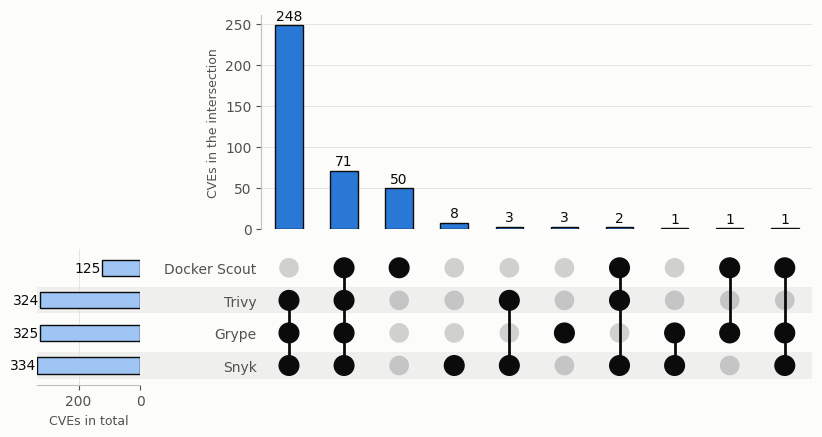

In [9]:
# fig1_overlap_upset - UpSet diagram for DOCKERFILE-jvm
dockerfile_jvm = direct[direct.image == 'DOCKERFILE-jvm']
contents = {scanner: set(dockerfile_jvm[dockerfile_jvm.scanner == scanner].vuln_id) for scanner in SCANNERS}
union_all = set.union(*contents.values())
common_all = set.intersection(*contents.values())
print(f'DOCKERFILE-jvm: union = {len(union_all)}, common to all 4 = {len(common_all)} '
      f'({len(common_all)/len(union_all)*100:.1f}%)')

upset_data = from_contents(contents)
fig = plt.figure(figsize=(10, 4.8))
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='cardinality',
              facecolor=INK, element_size=None)
upset_axes = upset.plot(fig=fig)
upset_axes['intersections'].set_ylabel(T('CVEs in the intersection'), fontsize=9)
upset_axes['totals'].set_xlabel(T('CVEs in total'), fontsize=9)
for patch in upset_axes['intersections'].patches:
    patch.set_facecolor('#2a78d6')
for patch in upset_axes['totals'].patches:
    patch.set_facecolor('#9ec5f4')
save_fig(fig, 'fig1_overlap_upset')
plt.show()

In [10]:
# Per-image, per-layer agreement (common-to-4 / union)
agree_rows = []
for image in IMAGES_ORDER:
    for layer in ('os', 'app'):
        subset = direct[(direct.image == image) & (direct.layer == layer)]
        union = subset.vuln_id.nunique()
        if union == 0:
            continue
        common = len(set.intersection(*[set(subset[subset.scanner == scanner].vuln_id) for scanner in SCANNERS]))
        agree_rows.append(dict(image=image, layer=layer, union=union, common4=common,
                               agreement=f'{common/union*100:.1f}%'))
agree_tab = pd.DataFrame(agree_rows)
print('Per-image, per-layer agreement (common-to-4 / union):')
display(agree_tab)

Per-image, per-layer agreement (common-to-4 / union):


,image,layer,union,common4,agreement
0,DOCKERFILE-jvm,os,331,21,6.3%
1,DOCKERFILE-jvm,app,60,47,78.3%
2,DOCKERFILE-jvm-alpine,os,40,32,80.0%
3,DOCKERFILE-jvm-alpine,app,52,47,90.4%
4,DOCKERFILE-jvm-corretto,os,14,7,50.0%
5,DOCKERFILE-jvm-corretto,app,52,47,90.4%
6,JIB-jvm,os,288,65,22.6%
7,JIB-jvm,app,52,47,90.4%
8,BUILDPACK-jvm,os,380,79,20.8%
9,BUILDPACK-jvm,app,139,49,35.3%


In [11]:
# Layer-classification disagreement note (pooled vs per-layer)
dockerfile_jvm = direct[direct.image == 'DOCKERFILE-jvm']
pooled = set.intersection(*[set(dockerfile_jvm[dockerfile_jvm.scanner == scanner].vuln_id) for scanner in SCANNERS])
per_layer = {layer: set.intersection(*[set(dockerfile_jvm[(dockerfile_jvm.layer == layer)
                                                          & (dockerfile_jvm.scanner == scanner)].vuln_id)
                                       for scanner in SCANNERS]) for layer in ('os', 'app')}
split = pooled - (per_layer['os'] | per_layer['app'])
print(f'Pooled common-4 = {len(pooled)}, os = {len(per_layer["os"])}, app = {len(per_layer["app"])}, '
      f'split across layers = {len(split)}')

Pooled common-4 = 71, os = 21, app = 47, split across layers = 3


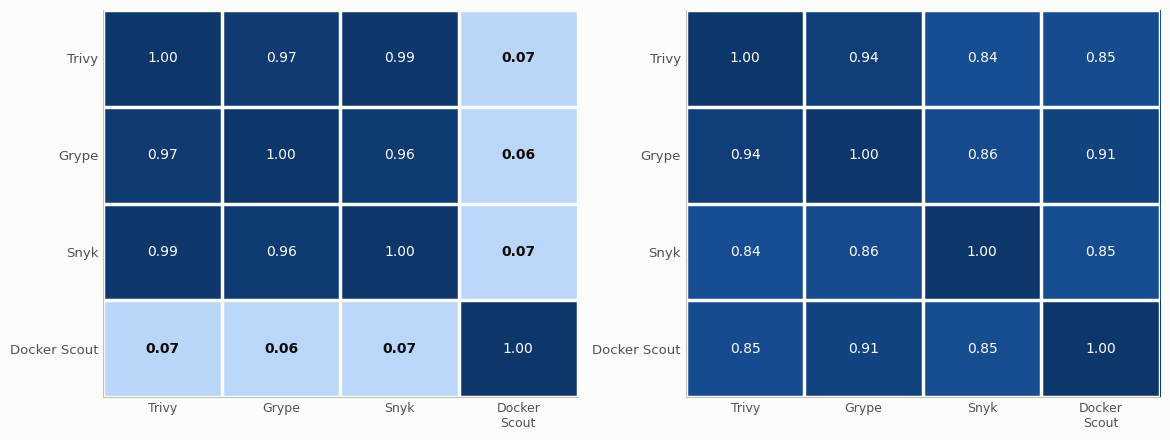

In [12]:
# fig2_jaccard_agreement - Jaccard similarity by layer for DOCKERFILE-jvm
dockerfile_jvm = direct[direct.image == 'DOCKERFILE-jvm']

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
for ax, layer, title in ((axes[0], 'os', T('OS layer (RPM)')),
                         (axes[1], 'app', T('application layer (Java)'))):
    layer_findings = dockerfile_jvm[dockerfile_jvm.layer == layer]
    scanner_sets = {scanner: set(layer_findings[layer_findings.scanner == scanner].vuln_id) for scanner in SCANNERS}
    jaccard = np.ones((len(SCANNERS), len(SCANNERS)))
    for i, scanner_a in enumerate(SCANNERS):
        for j, scanner_b in enumerate(SCANNERS):
            set_a, set_b = scanner_sets[scanner_a], scanner_sets[scanner_b]
            jaccard[i, j] = len(set_a & set_b) / len(set_a | set_b) if (set_a | set_b) else np.nan
    ax.grid(False)
    ax.imshow(jaccard, cmap=CMAP_SEQ, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(np.arange(-.5, len(SCANNERS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(SCANNERS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2.5); ax.tick_params(which='both', length=0)
    for i in range(len(SCANNERS)):
        for j in range(len(SCANNERS)):
            ax.text(j, i, f'{jaccard[i, j]:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if jaccard[i, j] >= 0.55 else INK,
                    fontweight='bold' if i != j and jaccard[i, j] < 0.2 else 'normal')
    ax.set_xticks(range(len(SCANNERS)))
    ax.set_xticklabels([scanner.replace('Docker ', 'Docker\n') for scanner in SCANNERS], fontsize=9)
    ax.set_yticks(range(len(SCANNERS))); ax.set_yticklabels(SCANNERS, fontsize=9.5)
fig.tight_layout(); save_fig(fig, 'fig2_jaccard_agreement'); plt.show()

### 3.2 Severity disagreement

**Result:** agreeing a CVE exists is not agreeing on its severity. Scanner pairs
without Snyk agree 94-99% on labels; every pair with Snyk drops to 72-76%. Fleiss
kappa on labels is 0.70 overall (substantial), stable on the application layer
(0.69-0.71) but collapsing to 0.06 on Alpine system packages. On the shared app CVEs
the 16 disagreements are all Snyk shifting by exactly one level. Numeric CVSS
disagreement traces to the source: Red Hat scores lower or equal to NVD 88% of the time. The three smallest system-layer samples (Corretto with 7 common CVEs, native-micro and JIB-native with 4 each) are shown for completeness but are too small to be reliable; only native-sbom app is left as n.d. because no CVE is common to all four there.

In [13]:
# Pairwise severity agreement on DOCKERFILE-jvm common CVEs
dockerfile_jvm = direct[direct.image == 'DOCKERFILE-jvm']
sev_rank = {severity: rank for rank, severity in enumerate(SEV_ORDER)}
top_severity = (dockerfile_jvm.assign(rank=dockerfile_jvm.severity.map(sev_rank))
                .sort_values('rank')
                .drop_duplicates(['scanner', 'vuln_id']))
severity_by_scanner = top_severity.pivot(index='vuln_id', columns='scanner', values='severity').dropna()

pair_agreement = pd.DataFrame(index=SCANNERS, columns=SCANNERS, dtype=float)
for scanner_a, scanner_b in itertools.combinations(SCANNERS, 2):
    agreement_pct = (severity_by_scanner[scanner_a] == severity_by_scanner[scanner_b]).mean() * 100
    pair_agreement.loc[scanner_a, scanner_b] = pair_agreement.loc[scanner_b, scanner_a] = round(agreement_pct, 1)
print(f'{len(severity_by_scanner)} CVEs common to all 4 on DOCKERFILE-jvm:')
display(pair_agreement)

71 CVEs common to all 4 on DOCKERFILE-jvm:


,Trivy,Grype,Snyk,Docker Scout
Trivy,NaN,98.6,76.1,94.4
Grype,98.6,NaN,74.6,95.8
Snyk,76.1,74.6,NaN,71.8
Docker Scout,94.4,95.8,71.8,NaN


In [14]:
# Severity-LABEL agreement + Fleiss kappa per image/layer.
# For each CVE common to all 4 scanners, agreement = share where all 4 assign the same
# severity label; kappa is Fleiss' kappa over the 5 severity categories. This is agreement on the
# severity LABEL, distinct from agreement on set membership (who reports a CVE at all).
# p_i, p_j, P_e follow the standard Fleiss' kappa notation.
def fleiss_kappa(count_matrix):
    n_items = len(count_matrix)
    n = count_matrix[0].sum()
    if n_items == 0 or n < 2:
        return float('nan')
    p_i = (np.sum(count_matrix * count_matrix, axis=1) - n) / (n * (n - 1))
    p_j = count_matrix.sum(axis=0) / (n_items * n)
    P_e = np.sum(p_j ** 2)
    return float('nan') if np.isclose(P_e, 1.0) else (p_i.mean() - P_e) / (1 - P_e)

sev_rank = {severity: rank for rank, severity in enumerate(SEV_ORDER)}
rows, matrices_by_layer = [], {'os': [], 'app': []}
for image in sorted(direct.image.unique()):
    for layer in ('os', 'app'):
        scan_subset = direct[(direct.image == image) & (direct.layer == layer)]
        if not len(scan_subset):
            continue
        top_severity = (scan_subset.assign(rank=scan_subset.severity.map(sev_rank)).sort_values('rank')
                        .drop_duplicates(['scanner', 'vuln_id']))
        # reindex to all 4 scanners so dropna() keeps only CVEs common to the whole quartet
        severity_by_scanner = (top_severity.pivot(index='vuln_id', columns='scanner', values='severity')
                               .reindex(columns=SCANNERS).dropna())
        if not len(severity_by_scanner):
            rows.append(dict(image=image, layer=layer, common4=0, agreement=np.nan, kappa=np.nan))
            continue
        category_counts = np.array([[(severity_by_scanner.loc[cve] == category).sum() for category in SEV_ORDER]
                                    for cve in severity_by_scanner.index])
        matrices_by_layer[layer].append(category_counts)
        rows.append(dict(image=image, layer=layer, common4=len(severity_by_scanner),
                         agreement=round((severity_by_scanner.nunique(axis=1) == 1).mean() * 100, 1),
                         kappa=round(fleiss_kappa(category_counts), 2)))
sev_ag = pd.DataFrame(rows)

aggregate_rows = []
for layer in ('os', 'app'):
    layer_counts = np.vstack(matrices_by_layer[layer])
    aggregate_rows.append(dict(layer=layer, common4=layer_counts.shape[0],
                               agreement=round((layer_counts.max(axis=1) == 4).mean() * 100, 1),
                               kappa=round(fleiss_kappa(layer_counts), 2)))
all_counts = np.vstack(matrices_by_layer['os'] + matrices_by_layer['app'])
aggregate_rows.append(dict(layer='os+app', common4=all_counts.shape[0],
                           agreement=round((all_counts.max(axis=1) == 4).mean() * 100, 1),
                           kappa=round(fleiss_kappa(all_counts), 2)))

print('severity-label agreement and Fleiss kappa per image/layer:')
display(sev_ag)
print('Aggregate over all images:')
display(pd.DataFrame(aggregate_rows))

severity-label agreement and Fleiss kappa per image/layer:


,image,layer,common4,agreement,kappa
0,BUILDPACK-jvm,os,79,86.1,0.87
1,BUILDPACK-jvm,app,49,63.3,0.69
2,DOCKERFILE-jvm,os,21,90.5,0.92
3,DOCKERFILE-jvm,app,47,66.0,0.71
4,DOCKERFILE-jvm-alpine,os,32,9.4,0.06
5,DOCKERFILE-jvm-alpine,app,47,66.0,0.71
6,DOCKERFILE-jvm-corretto,os,7,100.0,1.00
7,DOCKERFILE-jvm-corretto,app,47,66.0,0.71
8,DOCKERFILE-native,os,90,63.3,0.70
9,DOCKERFILE-native-micro,os,4,50.0,0.47


Aggregate over all images:


,layer,common4,agreement,kappa
0,os,392,63.5,0.67
1,app,237,65.4,0.71
2,os+app,629,64.2,0.70


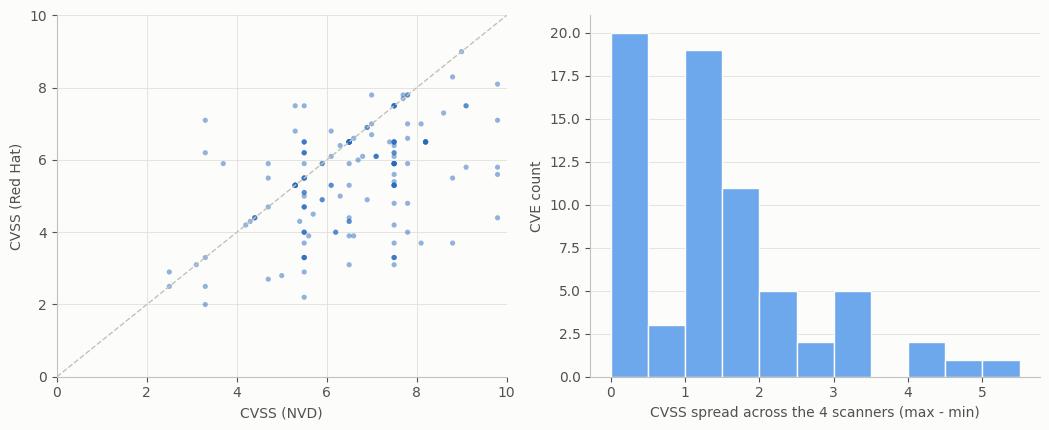

NVD vs Red Hat: 169 OS CVEs, Red Hat lower or equal in 88% of cases
CVSS spread: 69 CVEs with scores from all 4; identical: 25%


In [15]:
# fig3_cvss_sources - NVD vs Red Hat scatter (left) + CVSS spread across the 4 scanners (right).
# The LEFT panel re-reads the raw Trivy reports on purpose: df keeps only ONE collapsed cvss per
# finding (parse_trivy takes the first of nvd/redhat/ghsa/bitnami), whereas Trivy's raw output
# records the NVD and Red Hat V3 scores side by side - the only way to compare the two sources
# for the same CVE. Restricted to os-pkgs (system layer) on three representative RHEL images.
# The RIGHT panel needs no re-read: it uses df.cvss directly.
cvss_rows = []
for image in ['DOCKERFILE-jvm', 'JIB-jvm', 'DOCKERFILE-native']:
    trivy_report = load(os.path.join('results', PREFIX + image, 'trivy.json'))
    if trivy_report is None:
        continue
    for result in trivy_report.get('Results') or []:
        if result.get('Class') != 'os-pkgs':
            continue
        for vuln in result.get('Vulnerabilities') or []:
            cvss_scores = vuln.get('CVSS') or {}
            nvd_score = (cvss_scores.get('nvd') or {}).get('V3Score')
            redhat_score = (cvss_scores.get('redhat') or {}).get('V3Score')
            if nvd_score is not None and redhat_score is not None:
                cvss_rows.append(dict(image=image, cve=vuln.get('VulnerabilityID'),
                                      nvd=nvd_score, redhat=redhat_score))
cvss_df = pd.DataFrame(cvss_rows).drop_duplicates('cve')
score_diff = cvss_df.redhat - cvss_df.nvd

scored_findings = direct[(direct.image == 'DOCKERFILE-jvm') & direct.cvss.notna()]
cvss_by_scanner = scored_findings.pivot_table(index='vuln_id', columns='scanner', values='cvss', aggfunc='max')
scored_by_all4 = cvss_by_scanner.dropna()
spread = scored_by_all4.max(axis=1) - scored_by_all4.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4))
ax = axes[0]
ax.scatter(cvss_df.nvd, cvss_df.redhat, s=14, alpha=0.5, color='#256abf', edgecolor='none')
ax.plot([0, 10], [0, 10], color=BASELINE, linewidth=1, linestyle='--')
ax.set_xlabel('CVSS (NVD)'); ax.set_ylabel('CVSS (Red Hat)')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax = axes[1]
ax.hist(spread, bins=np.arange(0, spread.max() + 0.5, 0.5), color='#6da7ec', edgecolor=SURFACE)
ax.set_xlabel(T('CVSS spread across the 4 scanners (max - min)'))
ax.set_ylabel(T('CVE count'))
ax.grid(axis='x', visible=False)
fig.tight_layout()
save_fig(fig, 'fig3_cvss_sources')
plt.show()

print(f'NVD vs Red Hat: {len(cvss_df)} OS CVEs, Red Hat lower or equal in {(score_diff <= 0).mean()*100:.0f}% of cases')
print(f'CVSS spread: {len(scored_by_all4)} CVEs with scores from all 4; identical: {(spread == 0).mean()*100:.0f}%')

---
## 4. Image variant detections

### 4.1 Build method

**Result:** build method matters only through the base image. Dockerfile vs Jib give
near-identical results on comparable bases. CNB (buildpack) forces its own base and
adds 83 unique CVEs in Go lifecycle modules, plus more high-severity system CVEs,
despite carrying 55 fewer OS packages.

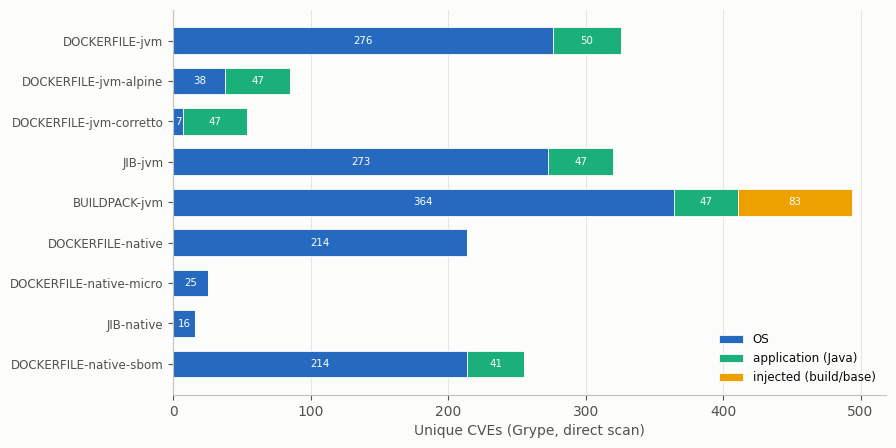

In [16]:
# fig4_build_decomposition - CVE decomposition: OS / app / injected (Grype, direct scans).
# Uses df.artifact_type (Grype's native artifact type) instead of re-reading grype.json.
def categorize_artifact(artifact_type):
    if artifact_type in ('rpm', 'apk', 'deb'):
        return 'OS'
    if artifact_type == 'java-archive':
        return 'application (Java)'
    return 'injected (build/base)'

grype_direct = df[(df.scanner == 'Grype') & (df.input == 'direct')].copy()
grype_direct['category'] = grype_direct.artifact_type.map(categorize_artifact)
decomposition = (grype_direct.groupby(['image', 'category']).vuln_id.nunique()
                 .unstack('category').fillna(0).astype(int)
                 .reindex(index=IMAGES_ORDER)[['OS', 'application (Java)', 'injected (build/base)']])

fig, ax = plt.subplots(figsize=(9.2, 5.0))
y_positions = np.arange(len(decomposition))
category_colors = {'OS': '#256abf', 'application (Java)': '#1baf7a', 'injected (build/base)': '#eda100'}
stack_offset = np.zeros(len(decomposition))
for category in decomposition.columns:
    ax.barh(y_positions, decomposition[category], left=stack_offset, height=0.66,
            label=T(category), color=category_colors[category], edgecolor=SURFACE, linewidth=0.6)
    for row_i, (count, offset) in enumerate(zip(decomposition[category], stack_offset)):
        if count > 0:
            ax.text(offset + count / 2, row_i, str(int(count)), ha='center', va='center',
                    fontsize=7.4, color='white')
    stack_offset += decomposition[category].values
ax.set_yticks(y_positions); ax.set_yticklabels(decomposition.index, fontsize=8.6)
ax.invert_yaxis()
ax.set_xlabel(T('Unique CVEs (Grype, direct scan)'))
ax.grid(axis='y', visible=False)
ax.legend(fontsize=8.6, loc='lower right')
save_fig(fig, 'fig4_build_decomposition')
plt.show()

In [17]:
# Package counts per image (Trivy)
def trivy_pkg_inventory(image):
    trivy_report = load(os.path.join('results', PREFIX + image, 'trivy.json'))
    inventory = {'OS': set(), 'Java': set(), 'Go': set()}
    if trivy_report is None:
        return {category: 0 for category in inventory}
    for result in trivy_report.get('Results') or []:
        result_class, pkg_type = result.get('Class'), result.get('Type')
        for package in result.get('Packages') or []:
            pkg_key = (package.get('Name'), package.get('Version'))
            if result_class == 'os-pkgs':
                inventory['OS'].add(pkg_key)
            elif result_class == 'lang-pkgs' and pkg_type == 'jar':
                inventory['Java'].add(pkg_key)
            elif result_class == 'lang-pkgs' and pkg_type in ('gobinary', 'gomod'):
                inventory['Go'].add(pkg_key)
    return {category: len(packages) for category, packages in inventory.items()}

inventory_per_image = {image: trivy_pkg_inventory(image) for image in IMAGES_ORDER}
pkg_tbl = pd.DataFrame(inventory_per_image).T[['OS', 'Java', 'Go']].reindex(IMAGES_ORDER)
print('Package counts per image (Trivy):')
display(pkg_tbl)

Package counts per image (Trivy):


,OS,Java,Go
DOCKERFILE-jvm,189,154,0
DOCKERFILE-jvm-alpine,73,154,0
DOCKERFILE-jvm-corretto,115,154,0
JIB-jvm,133,154,0
BUILDPACK-jvm,134,157,38
DOCKERFILE-native,106,0,0
DOCKERFILE-native-micro,21,0,0
JIB-native,22,0,0
DOCKERFILE-native-sbom,106,0,0


### 4.2 JVM vs native compilation

**Result:** every JVM image detects 5/5 reference CVEs; plain native images detect
0/5 (the Maven code is compiled in but invisible to scanners). Only
DOCKERFILE-native-sbom exposes them, and only to Grype and Scout (3/5). Its embedded
SBOM retains 41 of 47 application CVEs (87%); the 6 losses are 5 true negatives from
tree-shaking plus 1 false negative (the PostgreSQL driver, absent from the SBOM).

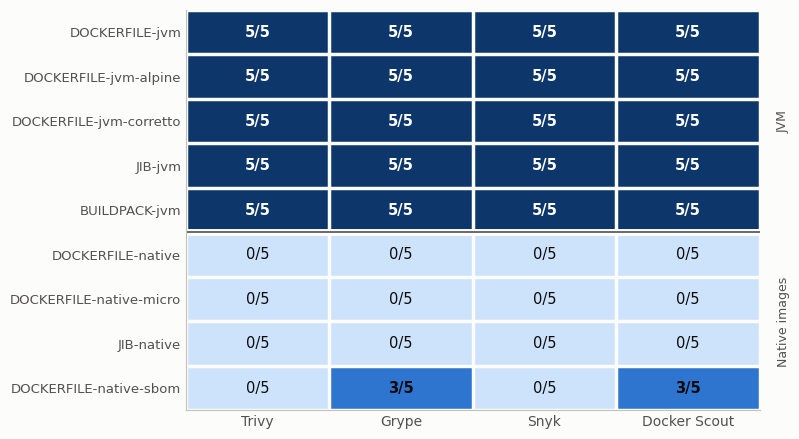

In [18]:
# fig5_ground_truth - Detection of 5 reference CVEs across 9 images
detection_matrix = pd.DataFrame(0, index=IMAGES_ORDER, columns=SCANNERS)
gt_findings = direct[direct.vuln_id.isin(GROUND_TRUTH)]
for (image, scanner), count in gt_findings.groupby(['image', 'scanner'])['vuln_id'].nunique().items():
    detection_matrix.loc[image, scanner] = count

fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.grid(False)
ax.imshow(detection_matrix.values, cmap=CMAP_SEQ, vmin=0, vmax=5, aspect='auto')
ax.set_xticks(np.arange(-.5, len(SCANNERS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(IMAGES_ORDER), 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2.5)
ax.tick_params(which='both', length=0)
for i in range(len(IMAGES_ORDER)):
    for j in range(len(SCANNERS)):
        count = int(detection_matrix.iloc[i, j])
        ax.text(j, i, f'{count}/5', ha='center', va='center', fontsize=10.5,
                color='white' if count >= 4 else INK,
                fontweight='bold' if count > 0 else 'normal')
ax.set_xticks(range(len(SCANNERS))); ax.set_xticklabels(SCANNERS, fontsize=10)
ax.set_yticks(range(len(IMAGES_ORDER))); ax.set_yticklabels(IMAGES_ORDER, fontsize=9.5)
ax.axhline(4.5, color=SURFACE, linewidth=5)
ax.axhline(4.5, color=INK2, linewidth=1.2)
ax.text(3.62, 2.0, 'JVM', rotation=90, va='center', color=INK2, fontsize=9)
ax.text(3.62, 6.5, T('Native images (GraalVM)').split('(')[0].strip(), rotation=90, va='center', color=INK2, fontsize=9)
save_fig(fig, 'fig5_ground_truth')
plt.show()

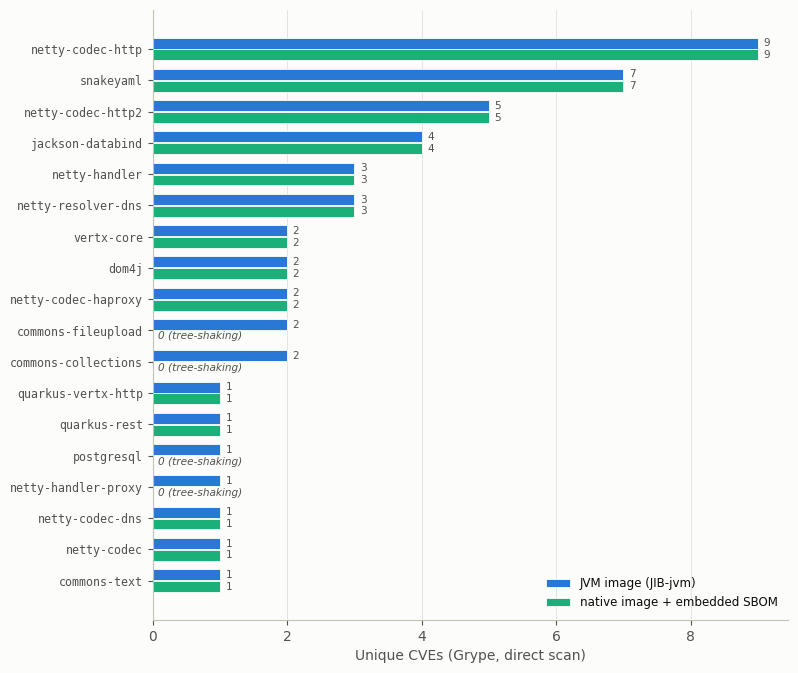

CVE-only: JVM = 47, native+SBOM = 41


In [19]:
# fig6_treeshaking_all_deps - CVEs per dependency: JVM vs native+SBOM
jvm_deps = app[(app.image == 'JIB-jvm') & (app.scanner == 'Grype')].groupby('artifact')['vuln_id'].nunique()
native_deps = app[(app.image == 'DOCKERFILE-native-sbom') & (app.scanner == 'Grype')].groupby('artifact')['vuln_id'].nunique()
per_dep = pd.DataFrame({'jvm': jvm_deps, 'native': native_deps}).fillna(0).astype(int)
per_dep = per_dep[per_dep.sum(axis=1) > 0].sort_values('jvm')

fig, ax = plt.subplots(figsize=(8.2, 0.34 * len(per_dep) + 1.8))
y_positions = np.arange(len(per_dep))
bar_height = 0.38
ax.barh(y_positions + bar_height / 2, per_dep['jvm'], height=bar_height * 0.92, color='#2a78d6',
        label=T('JVM image (JIB-jvm)'), edgecolor=SURFACE, linewidth=0.6)
ax.barh(y_positions - bar_height / 2, per_dep['native'], height=bar_height * 0.92, color='#1baf7a',
        label=T('native image + embedded SBOM'), edgecolor=SURFACE, linewidth=0.6)
for row_i, (jvm_count, native_count) in enumerate(zip(per_dep['jvm'], per_dep['native'])):
    ax.text(jvm_count + 0.08, row_i + bar_height / 2, str(jvm_count), va='center', fontsize=7.6, color=INK2)
    ax.text(native_count + 0.08, row_i - bar_height / 2, str(native_count) if native_count else '0 (tree-shaking)',
            va='center', fontsize=7.6, color=INK2, style='normal' if native_count else 'italic')
ax.set_yticks(y_positions); ax.set_yticklabels(per_dep.index, fontsize=8.4, family='DejaVu Sans Mono')
ax.set_xlabel(T('Unique CVEs (Grype, direct scan)'))
ax.grid(axis='y', visible=False)
ax.legend(fontsize=8.6, loc='lower right')
save_fig(fig, 'fig6_treeshaking_all_deps')
plt.show()

jvm_app = app[(app.image == 'JIB-jvm') & (app.scanner == 'Grype')]
native_app = app[(app.image == 'DOCKERFILE-native-sbom') & (app.scanner == 'Grype')]
print(f'CVE-only: JVM = {jvm_app.vuln_id.nunique()}, native+SBOM = {native_app.vuln_id.nunique()}')

In [20]:
# The 6 CVEs absent from native+SBOM vs JVM
jvm_cves = set(app[(app.image == 'JIB-jvm') & (app.scanner == 'Grype')].vuln_id)
nat_cves = set(app[(app.image == 'DOCKERFILE-native-sbom') & (app.scanner == 'Grype')].vuln_id)
missing_cves = jvm_cves - nat_cves
print(f'{len(missing_cves)} CVEs in JVM but not in native+SBOM:')
for cve in sorted(missing_cves):
    pkgs = sorted(set(app[(app.image == 'JIB-jvm') & (app.scanner == 'Grype') & (app.vuln_id == cve)].artifact))
    print(f'  {cve}: {pkgs}')

6 CVEs in JVM but not in native+SBOM:
  CVE-2015-6420: ['commons-collections']
  CVE-2015-7501: ['commons-collections']
  CVE-2023-24998: ['commons-fileupload']
  CVE-2025-48976: ['commons-fileupload']
  CVE-2026-42198: ['postgresql']
  CVE-2026-42578: ['netty-handler-proxy']


### 4.3 Image size vs CVEs

**Result:** image size does not predict CVE count (no clear trend across the nine images). Corretto is the largest
image in the study (795 MB) yet among the least vulnerable.

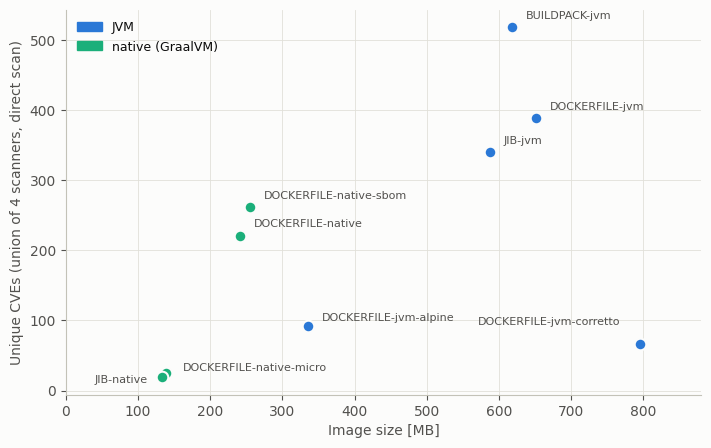

In [21]:
# fig7_size_vs_cves
SIZES_MB = {
    'DOCKERFILE-jvm': 651, 'DOCKERFILE-jvm-alpine': 335, 'DOCKERFILE-jvm-corretto': 795,
    'JIB-jvm': 587, 'BUILDPACK-jvm': 618, 'DOCKERFILE-native': 241,
    'DOCKERFILE-native-micro': 139, 'JIB-native': 133, 'DOCKERFILE-native-sbom': 255,
}
union_cves = direct.groupby('image')['vuln_id'].nunique()

fig, ax = plt.subplots(figsize=(8.2, 5.0))
label_offsets = {'DOCKERFILE-jvm': (10, 6), 'DOCKERFILE-jvm-alpine': (10, 4),
                 'DOCKERFILE-jvm-corretto': (-14, 14), 'JIB-jvm': (10, 6), 'BUILDPACK-jvm': (10, 6),
                 'DOCKERFILE-native': (10, 6), 'DOCKERFILE-native-micro': (12, 2),
                 'JIB-native': (-10, -4), 'DOCKERFILE-native-sbom': (10, 6)}
for image in IMAGES_ORDER:
    is_jvm = image in JVM_IMAGES
    color = '#2a78d6' if is_jvm else '#1baf7a'
    size_mb, cve_count = SIZES_MB[image], union_cves[image]
    ax.scatter(size_mb, cve_count, s=70, color=color, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    offset_x, offset_y = label_offsets[image]
    ax.annotate(image, (size_mb, cve_count), textcoords='offset points', xytext=(offset_x, offset_y),
                fontsize=8, color=INK2, ha='left' if offset_x > 0 else 'right')
ax.set_xlabel(T('Image size [MB]'))
ax.set_ylabel(T('Unique CVEs (union of 4 scanners, direct scan)'))
ax.legend(handles=[Patch(color='#2a78d6', label='JVM'), Patch(color='#1baf7a', label='native (GraalVM)')],
          fontsize=9, loc='upper left')
ax.set_xlim(0, 880)
save_fig(fig, 'fig7_size_vs_cves')
plt.show()

---
## 5. SBOM scanning

### 5.1 Retention

**Result:** retention depends on the layer and on whether the SBOM generator shares a
vendor with the scanner. Application-layer detections transfer freely (~100%, up to
117%), so even scanners with an empty direct scan recover 41 native app CVEs from a
Syft or Scout SBOM. System-layer detections mostly fail across vendors, from near 0%
to partial, because each tool encodes RPM metadata differently.

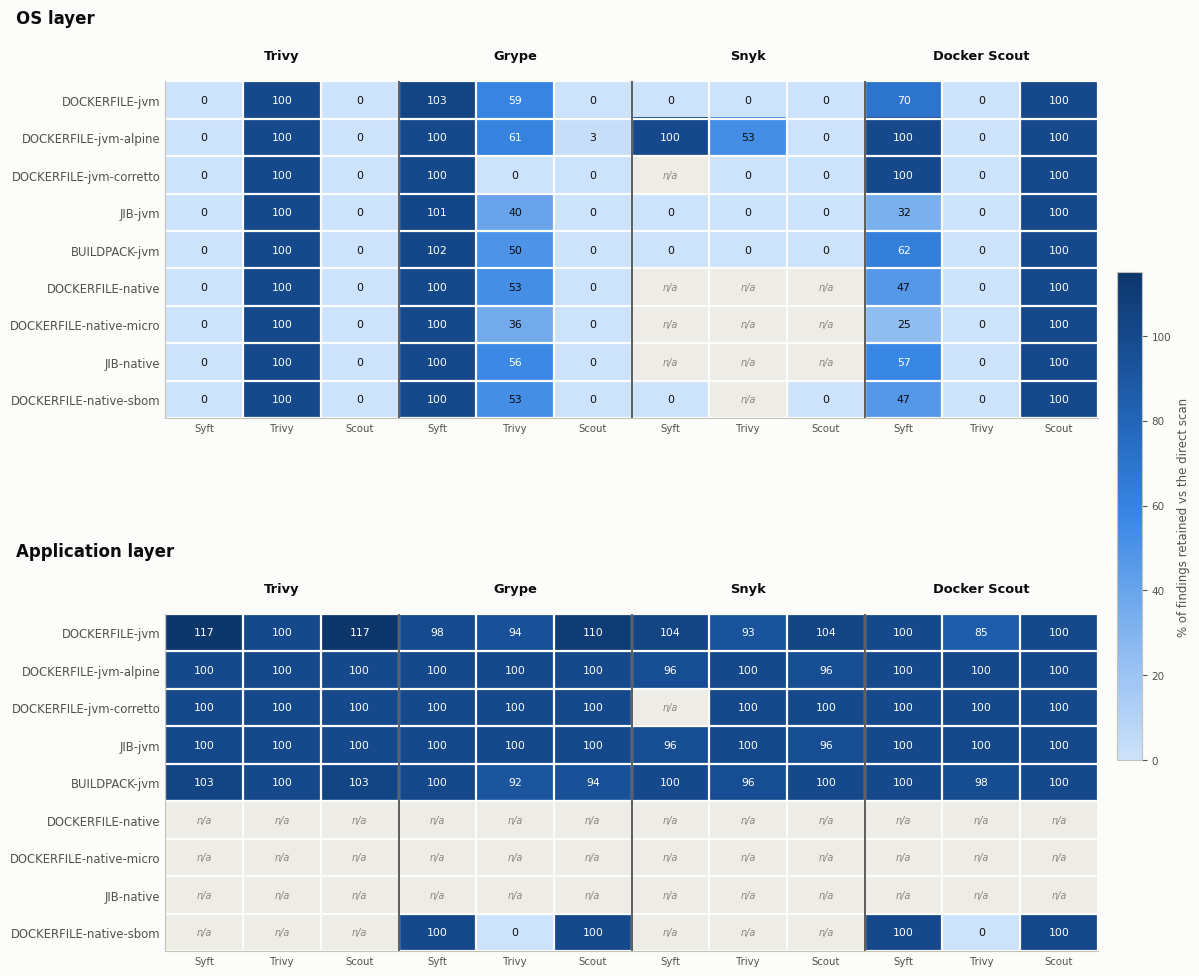

In [22]:
# fig8_sbom_retention - Heatmap of CVE retention when scanning via SBOM
GENS = ['syft', 'trivy', 'scout']
GEN_LBL = {'syft': 'Syft', 'trivy': 'Trivy', 'scout': 'Scout'}

def layer_retention(image, scanner, generator, layer):
    sbom_input = f'sbom-{generator}'
    scan_status = status[(status.image == image) & (status.scanner == scanner) & (status.input == sbom_input)].status
    scan_status = scan_status.iloc[0] if len(scan_status) else 'missing'
    direct_count = df[(df.image == image) & (df.scanner == scanner) & (df.input == 'direct') & (df.layer == layer)].vuln_id.nunique()
    if scan_status.startswith('error') or direct_count == 0:
        return np.nan
    sbom_count = df[(df.image == image) & (df.scanner == scanner) & (df.input == sbom_input) & (df.layer == layer)].vuln_id.nunique()
    return 100.0 * sbom_count / direct_count

scanner_generator_cols = [(scanner, generator) for scanner in SCANNERS for generator in GENS]
images = IMAGES_ORDER
fig, axes = plt.subplots(2, 1, figsize=(12.6, 10.0))
fig.subplots_adjust(hspace=0.58, top=0.93, bottom=0.06)
for ax, layer, title in [(axes[0], 'os', T('OS layer')), (axes[1], 'app', T('Application layer'))]:
    retention = np.array([[layer_retention(image, scanner, generator, layer)
                           for (scanner, generator) in scanner_generator_cols] for image in images])
    ax.imshow(np.nan_to_num(retention, nan=0), cmap=CMAP_SEQ, vmin=0, vmax=115, aspect='auto')
    for i in range(len(images)):
        for j in range(len(scanner_generator_cols)):
            value = retention[i, j]
            if np.isnan(value):
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, facecolor='#eeece7',
                                           edgecolor=SURFACE, lw=1.5))
                ax.text(j, i, T('n/a'), ha='center', va='center', fontsize=7, color=MUTED, style='italic')
            else:
                ax.text(j, i, f'{value:.0f}', ha='center', va='center', fontsize=7.8,
                        color='white' if value >= 55 else INK)
    ax.set_xticks(np.arange(-.5, len(scanner_generator_cols), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(images), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=1.6); ax.grid(which='major', visible=False)
    ax.tick_params(which='both', length=0)
    ax.set_xticks(range(len(scanner_generator_cols)))
    ax.set_xticklabels([GEN_LBL[generator] for (scanner, generator) in scanner_generator_cols], fontsize=7.3)
    ax.set_yticks(range(len(images))); ax.set_yticklabels(images, fontsize=8.4)
    for k, scanner in enumerate(SCANNERS):
        ax.text(k * 3 + 1, -1.0, scanner, ha='center', va='bottom', fontsize=9.4, fontweight='bold')
        if k > 0:
            ax.axvline(k * 3 - 0.5, color=INK2, lw=1.3)
    ax.annotate(title, xy=(0, 1), xytext=(-0.16, 1.16), xycoords='axes fraction',
                fontsize=12, fontweight='bold', ha='left', va='bottom')
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, 115), cmap=CMAP_SEQ),
                        ax=axes, fraction=0.025, pad=0.02)
colorbar.set_label(T('% of findings retained vs the direct scan'), fontsize=8.5)
colorbar.ax.tick_params(labelsize=7.5)
save_fig(fig, 'fig8_sbom_retention')
plt.show()

In [23]:
# Application-layer CVEs on native images
INPUTS = ['direct', 'sbom-syft', 'sbom-trivy', 'sbom-scout']
def app_count(image, scanner, scan_input):
    scan_status = status[(status.image == image) & (status.scanner == scanner) & (status.input == scan_input)].status
    scan_status = scan_status.iloc[0] if len(scan_status) else 'missing'
    if scan_status.startswith('error'):
        return 'ERR'
    return df[(df.image == image) & (df.scanner == scanner)
              & (df.input == scan_input) & (df.layer == 'app')].vuln_id.nunique()

print('DOCKERFILE-native-sbom, application-layer CVEs:')
print(f"{'scanner':14}" + ''.join(f"{scan_input.replace('sbom-', ''):>10}" for scan_input in INPUTS))
for scanner in SCANNERS:
    print(f'{scanner:14}' + ''.join(f'{str(app_count("DOCKERFILE-native-sbom", scanner, scan_input)):>10}' for scan_input in INPUTS))

DOCKERFILE-native-sbom, application-layer CVEs:
scanner           direct      syft     trivy     scout
Trivy                  0        41         0        41
Grype                 41        41         0        41
Snyk                   0        41       ERR        41
Docker Scout          41        41         0        41


### 5.2 Inventory divergence

**Result:** Trivy's buildpack SBOM carries 162 duplicate entries (the same component
stored per layer), but duplicates do not inflate CVE counts. The real cause of lost
system-layer transfer is metadata convention (distro id, source package, OS
declaration), illustrated by the alsa-lib RPM broken down below.

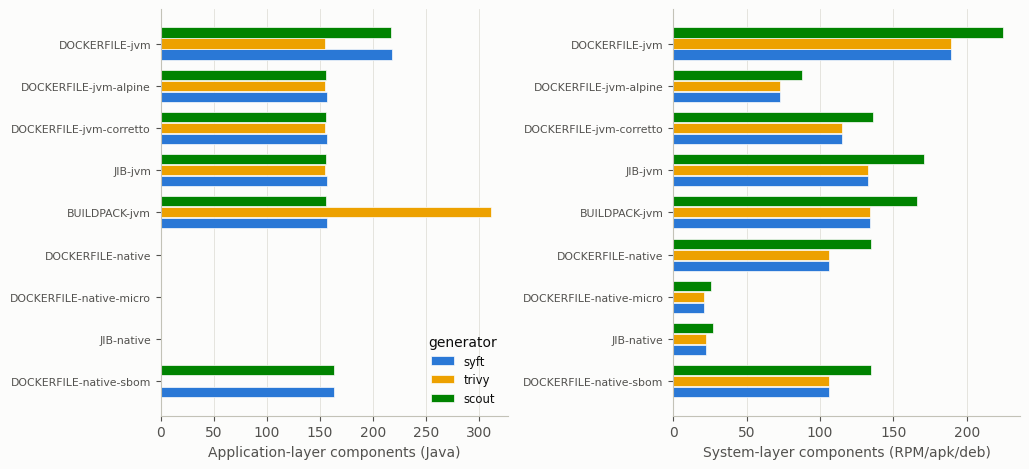

In [24]:
# fig9_sbom_inventory - Component counts per generator, split Java/system
def spdx_component_types(path):
    sbom = load(path)
    if sbom is None:
        return None
    type_counts = Counter()
    for package in sbom.get('packages', []) or []:
        purl = None
        for ext_ref in package.get('externalRefs', []) or []:
            if ext_ref.get('referenceType') == 'purl':
                purl = ext_ref.get('referenceLocator'); break
        if purl and purl.startswith('pkg:'):
            purl_type = purl[4:].split('/')[0]
        else:
            purl_type = '(no purl)'
        category = 'system' if purl_type in ('rpm', 'apk', 'deb') else ('Java' if purl_type == 'maven' else 'other')
        type_counts[category] += 1
    return type_counts

inventory_rows = []
for image in IMAGES_ORDER:
    for generator in ['syft', 'trivy', 'scout']:
        type_counts = spdx_component_types(os.path.join('results', PREFIX + image, 'sbom', generator, 'sbom.spdx.json'))
        if type_counts is None:
            continue
        inventory_rows.append(dict(image=image, generator=generator, system=type_counts['system'],
                                   Java=type_counts['Java'], other=type_counts.get('other', 0),
                                   total=sum(type_counts.values())))
inventory = pd.DataFrame(inventory_rows)
java_by_gen = inventory.pivot(index='image', columns='generator', values='Java').reindex(IMAGES_ORDER)[['syft', 'trivy', 'scout']]
system_by_gen = inventory.pivot(index='image', columns='generator', values='system').reindex(IMAGES_ORDER)[['syft', 'trivy', 'scout']]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.0))
generator_colors = {'syft': '#2a78d6', 'trivy': '#eda100', 'scout': '#008300'}
for ax, table, xlabel in [(axes[0], java_by_gen, T('Application-layer components (Java)')),
                          (axes[1], system_by_gen, T('System-layer components (RPM/apk/deb)'))]:
    y_positions = np.arange(len(table)); bar_height = 0.26
    for k, generator in enumerate(['syft', 'trivy', 'scout']):
        ax.barh(y_positions + (1 - k) * bar_height, table[generator], height=bar_height * 0.92,
                label=generator, color=generator_colors[generator], edgecolor=SURFACE, linewidth=0.5)
    ax.set_yticks(y_positions); ax.set_yticklabels(table.index, fontsize=7.8)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.grid(axis='y', visible=False)
axes[0].legend(fontsize=8.4, loc='lower right', title='generator')
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_fig(fig, 'fig9_sbom_inventory')
plt.show()

In [25]:
# Duplicate entries per SBOM
def spdx_keys(path):
    sbom = load(path)
    if sbom is None:
        return None
    keys = []
    for package in sbom.get('packages', []) or []:
        purl = next((ext_ref.get('referenceLocator') for ext_ref in package.get('externalRefs', []) or []
                     if ext_ref.get('referenceType') == 'purl'), None)
        keys.append(purl if purl else ('noref', package.get('name'), package.get('versionInfo')))
    return keys

dedup_rows = []
for image in IMAGES_ORDER:
    for generator in ['syft', 'trivy', 'scout']:
        keys = spdx_keys(os.path.join('results', PREFIX + image, 'sbom', generator, 'sbom.spdx.json'))
        if keys is None:
            continue
        dedup_rows.append(dict(image=image, generator=generator,
                               entries=len(keys), unique=len(set(keys)), duplicates=len(keys) - len(set(keys))))
dedup_df = pd.DataFrame(dedup_rows)
dup_tab = dedup_df.pivot(index='image', columns='generator', values='duplicates').reindex(IMAGES_ORDER)[['syft', 'trivy', 'scout']]
print('Duplicate entries per SBOM:')
print(dup_tab.fillna(0).astype(int).to_string())

Duplicate entries per SBOM:
generator                syft  trivy  scout
image                                      
DOCKERFILE-jvm              1      1      0
DOCKERFILE-jvm-alpine       1      1      0
DOCKERFILE-jvm-corretto     1      1      0
JIB-jvm                     1      1      0
BUILDPACK-jvm               9    162      0
DOCKERFILE-native           0      0      0
DOCKERFILE-native-micro     0      0      0
JIB-native                  0      0      0
DOCKERFILE-native-sbom      0      0      0


In [26]:
# alsa-lib RPM: the same package written three ways by Syft, Trivy and Scout.
# Each records the system-layer metadata differently, which is why an RPM finding does
# not transfer when one tool scans another tool's SBOM.
def spdx_packages(image, generator):
    sbom = load(os.path.join('results', PREFIX + image, 'sbom', generator, 'sbom.spdx.json'))
    return sbom.get('packages', []) if sbom else []

def purl_qualifiers(purl):
    return dict(q.split('=', 1) for q in purl.split('?', 1)[1].split('&')) if '?' in purl else {}

metadata_by_generator = {}
for generator in ['syft', 'trivy', 'scout']:
    packages = spdx_packages('DOCKERFILE-jvm', generator)
    alsa = next((p for p in packages if (p.get('name') or '').lower() == 'alsa-lib'), {})
    purl = next((ref.get('referenceLocator') for ref in alsa.get('externalRefs', []) or []
                 if ref.get('referenceType') == 'purl'), '')
    qualifiers = purl_qualifiers(purl)
    has_os_package = any(p.get('primaryPackagePurpose') == 'OPERATING-SYSTEM' for p in packages)
    cpe_count = sum(1 for ref in alsa.get('externalRefs', []) or [] if ref.get('referenceType') == 'cpe23Type')
    if 'distro' in qualifiers:
        distro = f"purl distro={qualifiers['distro']}"
    elif 'os_name' in qualifiers:
        distro = 'purl os_name+os_version'
    else:
        distro = '(none)'
    if qualifiers.get('upstream'):
        source = 'in purl (upstream)'
    elif alsa.get('sourceInfo'):
        source = 'in sourceInfo (text)'
    else:
        source = '(omitted)'
    metadata_by_generator[generator] = {
        'separate OS package': 'yes' if has_os_package else 'no',
        'distro recorded': distro,
        'source package recorded': source,
        'CPE identifiers': cpe_count,
        'supplier': (alsa.get('supplier') or 'NOASSERTION').replace('Organization: ', ''),
        'SPDX fields': len(alsa.keys()),
    }
alsa_tbl = pd.DataFrame(metadata_by_generator)[['syft', 'trivy', 'scout']]
print('alsa-lib 1.2.10-2.el8 (DOCKERFILE-jvm) as written by each SBOM generator:')
display(alsa_tbl)

alsa-lib 1.2.10-2.el8 (DOCKERFILE-jvm) as written by each SBOM generator:


,syft,trivy,scout
separate OS package,no,yes,no
distro recorded,purl distro=rhel-8.10,purl distro=redhat-8.10,purl os_name+os_version
source package recorded,in purl (upstream),in sourceInfo (text),(omitted)
CPE identifiers,8,0,0
supplier,"Red Hat, Inc.","Red Hat, Inc.",NOASSERTION
SPDX fields,13,13,9


### 5.3 Format control: SPDX vs CycloneDX

**Result:** SPDX and CycloneDX give identical CVE counts in all 14 successful
configurations (the 2 errors are the same Snyk RPM-only failure in both formats).
Losses come from metadata content and reader support, not the serialization format.

In [27]:
# CVE counts with SPDX vs CycloneDX (identical in all 16 configs)
rows = []
for image in ['DOCKERFILE-jvm', 'DOCKERFILE-native']:
    for generator in ['syft', 'trivy']:
        for scanner in SCANNERS:
            cdx_status_value = cdx_status[(cdx_status.image == image) & (cdx_status.scanner == scanner)
                                          & (cdx_status.input == f'cdx-{generator}')].status.iloc[0]
            cdx_count = cdx_df[(cdx_df.image == image) & (cdx_df.scanner == scanner)
                               & (cdx_df.input == f'cdx-{generator}')].vuln_id.nunique() if cdx_status_value == 'ok' else None
            spdx_status_value = status[(status.image == image) & (status.scanner == scanner)
                                       & (status.input == f'sbom-{generator}')].status.iloc[0]
            spdx_count = df[(df.image == image) & (df.scanner == scanner)
                            & (df.input == f'sbom-{generator}')].vuln_id.nunique() if spdx_status_value == 'ok' else None
            rows.append(dict(image=image, generator=generator, scanner=scanner,
                             SPDX=spdx_count if spdx_count is not None else 'error',
                             CycloneDX=cdx_count if cdx_count is not None else 'error'))
cdx_tab = pd.DataFrame(rows).set_index(['image', 'generator', 'scanner'])
print('CVE counts with SPDX vs CycloneDX:')
display(cdx_tab)
same = all(str(spdx) == str(cdx) for spdx, cdx in zip(cdx_tab.SPDX, cdx_tab.CycloneDX))
print(f'SPDX and CycloneDX produce identical results in all 16 configurations: {same}')

CVE counts with SPDX vs CycloneDX:


SPDX CycloneDX
image             generator scanner                      
DOCKERFILE-jvm    syft      Trivy            55        55
                            Grype           332       332
                            Snyk             58        58
                            Docker Scout    104       104
                  trivy     Trivy           324       324
                            Grype           210       210
                            Snyk             52        52
                            Docker Scout     47        47
DOCKERFILE-native syft      Trivy             0         0
                            Grype           214       214
                            Snyk          error     error
                            Docker Scout     44        44
                  trivy     Trivy           217       217
                            Grype           114       114
                            Snyk          error     error
                            Docker Scout      0         0

SPDX and CycloneDX produce identical results in all 16 configurations: True


---
## 6. Effectiveness against reference sources

### 6.1 Direct scan verification

**Result:** effectiveness is read on two axes, precision (are the reported findings real) and
recall (what share of the confirmed-CVE set a scanner catches), over the **whole** application
layer, not Maven alone: OSV also covers the Go modules that the Cloud Native Buildpacks lifecycle
injects, and the few Python packages. On the system layer the reference is Red Hat. The application
picture changes once Go is included: on Maven all four scanners reach ~97.5-100% recall, but Snyk
detects only **2** of the 72 confirmed Go CVEs (2.8% recall on Go), which drops its whole-app recall to
74.2%, while Docker Scout is the only tool that reports the PyPI packages. On the system layer Trivy,
Grype and Snyk reach ~99% on both axes, while Docker Scout catches only about a quarter of the
confirmed CVEs.

Application layer (all ecosystems): TP universe = 318 confirmed CVEs summed over 5 JVM images | by ecosystem: {'Maven': np.int64(994), 'Go': np.int64(235), 'PyPI': np.int64(6)}


,TP,FP,undecided,FN,precision,recall
scanner,,,,,,
Trivy,307,0,0,11,100.0,96.5
Grype,310,0,11,8,100.0,97.5
Snyk,236,10,20,82,95.9,74.2
Docker Scout,317,1,0,1,99.7,99.7


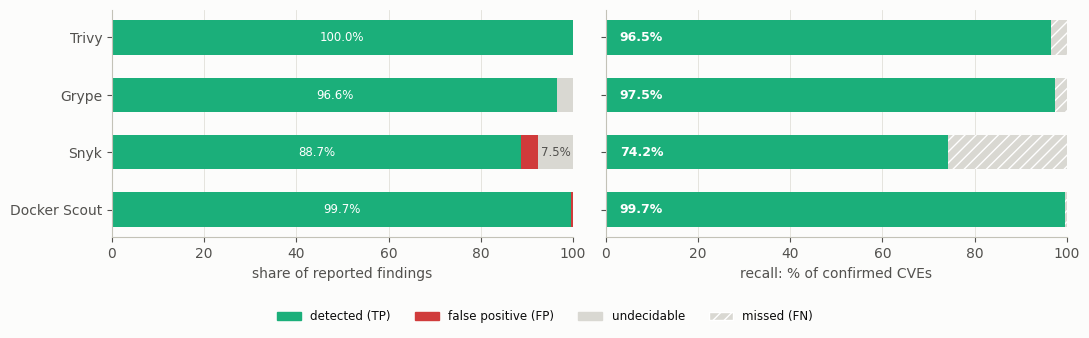

In [28]:
# Application-layer effectiveness (OSV): precision, recall and the undecidable share
prec = pd.read_csv('data/app_precision_findings.csv')


def effectiveness(findings, is_tp, is_fp, images, per_image):
    """Per-scanner TP / FP / undecidable / FN over a pooled-union confirmed-CVE reference.

    universe = CVEs that any scanner reports AND adjudication confirms as TP.
    Precision is computed among *decided* findings, TP / (TP + FP); a reported CVE that is
    neither TP nor FP is undecidable (OSV has no entry yet, or Red Hat has no data) and is
    set aside, not counted against precision. A scanner's FN = confirmed CVEs it did not
    report as TP, so recall = TP / |universe|. Recall is *relative*: a CVE missed by all
    four scanners cannot enter the universe, so it is an upper bound.

    per_image=True  -> unit is the (image, CVE) pair, distinct CVEs summed over images.
    per_image=False -> a CVE counts once, pooled across images (available mode, unused here).
    Both the application and the system layer are scored with per_image=True, so the
    reference universe is 318 (image, CVE) pairs on the app layer and 1381 on the OS layer.
    """
    scoped = findings[findings.image.isin(images)].copy()
    scoped['tp'], scoped['fp'] = is_tp(scoped), is_fp(scoped)
    image_groups = list(scoped.groupby('image')) if per_image else [('all', scoped)]
    universe = {image: set(group.loc[group.tp, 'cve']) for image, group in image_groups}
    rows = []
    for scanner in SCANNERS:
        TP = FP = UND = FN = 0
        for image, universe_cves in universe.items():
            scanner_findings = (scoped[(scoped.image == image) & (scoped.scanner == scanner)]
                                if per_image else scoped[scoped.scanner == scanner])
            tp_cves = set(scanner_findings.loc[scanner_findings.tp, 'cve'])
            fp_cves = set(scanner_findings.loc[scanner_findings.fp, 'cve']) - tp_cves
            und_cves = set(scanner_findings.cve) - tp_cves - fp_cves          # reported but not decided
            TP += len(tp_cves); FP += len(fp_cves); UND += len(und_cves)
            FN += len(universe_cves - tp_cves)
        rows.append(dict(scanner=scanner, TP=TP, FP=FP, undecided=UND, FN=FN,
                         precision=round(100 * TP / (TP + FP), 1) if TP + FP else np.nan,
                         recall=round(100 * TP / (TP + FN), 1) if TP + FN else np.nan))
    return pd.DataFrame(rows).set_index('scanner'), sum(len(cves) for cves in universe.values())


def plot_effectiveness(eff_table, fig_name):
    """Left panel: composition of reported findings (TP / FP / undecidable).
    Right panel: recall (TP detected vs FN missed) over the confirmed universe."""
    fig, (ax_precision, ax_recall) = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
    y_positions = np.arange(len(SCANNERS))[::-1]

    reported = eff_table[['TP', 'FP', 'undecided']].sum(axis=1)
    stack_offset = np.zeros(len(SCANNERS))
    for component, color, is_dark in [('TP', '#1baf7a', False), ('FP', '#d03b3b', False),
                                      ('undecided', '#d9d8d2', True)]:
        shares = np.array([eff_table.loc[scanner, component] / reported[scanner] * 100 if reported[scanner] else 0
                           for scanner in SCANNERS])
        ax_precision.barh(y_positions, shares, left=stack_offset, color=color, height=0.6)
        for y, share, offset in zip(y_positions, shares, stack_offset):
            if share >= 6:
                ax_precision.text(offset + share / 2, y, f'{share:.1f}%', ha='center', va='center',
                                  fontsize=8.5, color=INK2 if is_dark else 'white')
        stack_offset += shares
    ax_precision.set_xlim(0, 100); ax_precision.set_xlabel(T('share of reported findings'))
    ax_precision.grid(axis='y', visible=False)

    recall = np.array([eff_table.loc[scanner, 'recall'] for scanner in SCANNERS])
    ax_recall.barh(y_positions, recall, color='#1baf7a', height=0.6)
    ax_recall.barh(y_positions, 100 - recall, left=recall, color='#d9d8d2', height=0.6,
                   hatch='///', edgecolor='white', linewidth=0)
    for y, recall_value in zip(y_positions, recall):
        ax_recall.text(3, y, f'{recall_value:.1f}%', va='center', ha='left', fontsize=9,
                       color='white', fontweight='bold')
    ax_recall.set_xlim(0, 100); ax_recall.set_xlabel(T('recall: % of confirmed CVEs'))
    ax_recall.grid(axis='y', visible=False)

    ax_precision.set_yticks(y_positions); ax_precision.set_yticklabels(SCANNERS)
    fig.legend(handles=[Patch(color='#1baf7a', label=T('detected (TP)')),
                        Patch(color='#d03b3b', label=T('false positive (FP)')),
                        Patch(color='#d9d8d2', label=T('undecidable')),
                        Patch(facecolor='#d9d8d2', hatch='///', edgecolor='white',
                              label=T('missed (FN)'))],
               ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=8.6)
    fig.tight_layout(rect=[0, 0.06, 1, 1]); save_fig(fig, fig_name); plt.show()


prec_d = prec.drop_duplicates(['scanner', 'cve', 'coord'])   # used by the next cell
app_eff, app_uni = effectiveness(prec, lambda d: d.verdict.eq('TP'),
                                 lambda d: d.verdict.eq('FP'), JVM_IMAGES, per_image=True)
print(f'Application layer (all ecosystems): TP universe = {app_uni} confirmed CVEs '
      f'summed over {len(JVM_IMAGES)} JVM images | by ecosystem: {dict(prec.ecosystem.value_counts())}')
display(app_eff)
# fig10_app_precision_osv
plot_effectiveness(app_eff, 'fig10_app_precision_osv')

Recall by ecosystem (confirmed universe sizes: {'Maven': 240, 'Go': 72, 'PyPI': 6} )


,Trivy,Grype,Snyk,Docker Scout
Maven,97.9,99.2,97.5,100.0
Go,100.0,100.0,2.8,98.6
PyPI,0.0,0.0,0.0,100.0


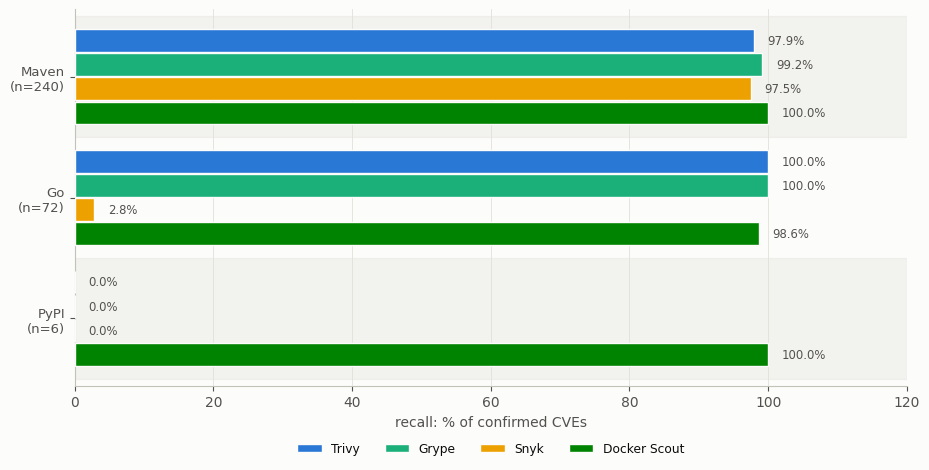

In [29]:
# fig12_app_ecosystem_recall : recall by ecosystem (Maven / Go / PyPI) per scanner
ECOS = ['Maven', 'Go', 'PyPI']


def recall_by_ecosystem(findings):
    scored = findings.copy(); scored['tp'] = scored.verdict.eq('TP')
    recall_rows, universe_sizes = {}, {}
    for ecosystem in ECOS:
        eco_findings = scored[scored.ecosystem == ecosystem]
        universe = {image: set(group.loc[group.tp, 'cve']) for image, group in eco_findings.groupby('image')}
        total = sum(len(cves) for cves in universe.values())
        universe_sizes[ecosystem] = total
        recall_rows[ecosystem] = {scanner: (100 * sum(len(set(eco_findings[(eco_findings.image == image)
                                                                           & (eco_findings.scanner == scanner)
                                                                           & eco_findings.tp].cve))
                                                       for image in universe) / total if total else np.nan)
                                  for scanner in SCANNERS}
    return pd.DataFrame(recall_rows).T, universe_sizes


recall_table, universe_sizes = recall_by_ecosystem(prec)
print('Recall by ecosystem (confirmed universe sizes:', universe_sizes, ')')
display(recall_table.round(1))

fig, ax = plt.subplots(figsize=(9.4, 4.8))
group_positions = np.arange(len(ECOS))[::-1] * 1.7
bar_height = 0.34
for idx, y in enumerate(group_positions):                      # alternating band per ecosystem
    if idx % 2 == 0:
        ax.axhspan(y - 0.85, y + 0.85, color=GRID, alpha=0.35, zorder=0)
for i, scanner in enumerate(SCANNERS):
    values = np.array([recall_table.loc[ecosystem, scanner] for ecosystem in ECOS])
    offset = (1.5 - i) * bar_height
    ax.barh(group_positions + offset, values, height=bar_height * 0.94, color=SCANNER_C[scanner],
            label=scanner, edgecolor=SURFACE, linewidth=1.0, zorder=3)
    for y, value in zip(group_positions, values):
        if not np.isnan(value):
            ax.text(value + 2, y + offset, f'{value:.1f}%', va='center', fontsize=8.4,
                    color=INK2, zorder=4)
ax.set_yticks(group_positions)
ax.set_yticklabels([f'{ecosystem}\n(n={universe_sizes[ecosystem]})' for ecosystem in ECOS], fontsize=9.5)
ax.set_xlim(0, 120); ax.set_xlabel(T('recall: % of confirmed CVEs'))
ax.set_ylim(group_positions.min() - 0.95, group_positions.max() + 0.95)
ax.grid(axis='y', visible=False)
ax.legend(fontsize=8.8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(); save_fig(fig, 'fig12_app_ecosystem_recall'); plt.show()

In [30]:
# The 7 imprecise Snyk findings
false_positives = prec_d[prec_d.verdict == 'FP']
too_fresh = prec_d[prec_d.verdict == 'too-fresh']
print('Snyk false positives (wrong module) and undecidable findings:')
print('False positives:')
display(false_positives[['cve', 'coord', 'scanner']].reset_index(drop=True))
print('Undecidable (no OSV entry):')
display(too_fresh[['cve', 'coord', 'scanner']].reset_index(drop=True))

Snyk false positives (wrong module) and undecidable findings:
False positives:


,cve,coord,scanner
0,CVE-2026-42587,io.netty:netty-codec,Snyk
1,CVE-2026-45536,io.netty:netty-transport-native-unix-common,Snyk
2,CVE-2025-66560,io.quarkus.vertx.utils:quarkus-vertx-utils,Snyk
3,CVE-2022-30635,stdlib,Docker Scout


Undecidable (no OSV entry):


,cve,coord,scanner
0,CVE-2015-4852,commons-collections:commons-collections,Snyk
1,CVE-2026-50559,io.quarkus:quarkus-vertx-http,Snyk
2,CVE-2026-9563,org.eclipse.parsson:parsson,Snyk
3,CVE-2026-54291,org.postgresql:postgresql,Snyk
4,CVE-2023-24531,stdlib,Grype
5,CVE-2026-27140,stdlib,Grype
6,CVE-2026-27143,stdlib,Grype
7,CVE-2024-24787,stdlib,Grype
8,CVE-2025-61731,stdlib,Grype
9,CVE-2025-61732,stdlib,Grype


OS layer: pooled TP universe = 1381 confirmed CVEs across 7 Red Hat images (per-image (image, CVE) units)


,TP,FP,undecided,FN,precision,recall
scanner,,,,,,
Trivy,1370,1,27,11,99.9,99.2
Grype,1375,1,6,6,99.9,99.6
Snyk,1378,10,24,3,99.3,99.8
Docker Scout,353,69,6,1028,83.6,25.6


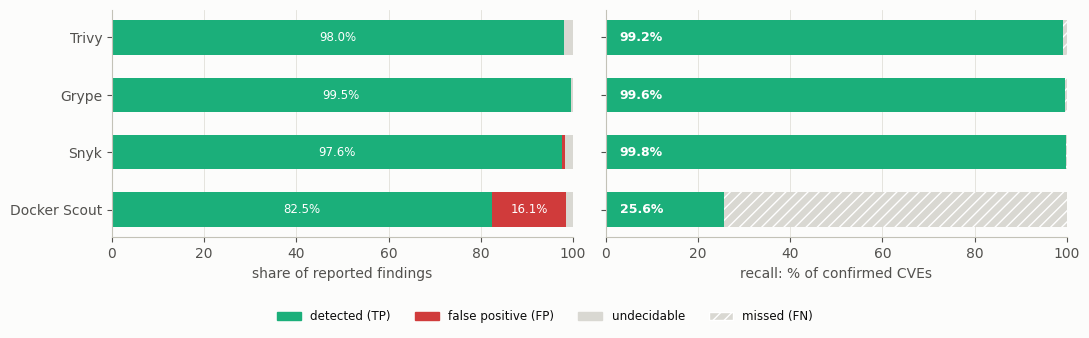

In [31]:
# OS-layer effectiveness (Red Hat): precision AND recall (TP / FP / FN)
osp = pd.read_csv('data/os_precision_findings.csv')
RH_IMAGES = sorted(osp.image.unique())
os_eff, os_uni = effectiveness(osp,
                               lambda d: d.verdict.isin(['TP-fixable', 'TP-nofix']),
                               lambda d: d.verdict.str.startswith('FP'),
                               RH_IMAGES, per_image=True)
print(f'OS layer: pooled TP universe = {os_uni} confirmed CVEs '
      f'across {len(RH_IMAGES)} Red Hat images (per-image (image, CVE) units)')
display(os_eff)
# fig11_os_precision_redhat
plot_effectiveness(os_eff, 'fig11_os_precision_redhat')

In [32]:
# Docker Scout per image (OS layer): confirmed CVEs it misses (FN) and its false positives
def scout_per_image(findings):
    scored = findings.copy()
    scored['tp'] = scored.verdict.isin(['TP-fixable', 'TP-nofix'])
    universe = {image: set(group.loc[group.tp, 'cve']) for image, group in scored.groupby('image')}
    rows = []
    for image, universe_cves in universe.items():
        scout = scored[(scored.image == image) & (scored.scanner == 'Docker Scout')]
        scout_tp = set(scout.loc[scout.tp, 'cve'])
        rows.append({'image': image, 'universe': len(universe_cves), 'TP': len(scout_tp),
                     'FN': len(universe_cves - scout_tp),
                     'FP': int(scout.verdict.str.startswith('FP').sum()),
                     'recall%': round(100 * len(scout_tp) / len(universe_cves), 1) if universe_cves else np.nan})
    return pd.DataFrame(rows).set_index('image').sort_values('recall%')


print('Docker Scout per image (OS layer): missed confirmed CVEs (FN) vs false positives:')
display(scout_per_image(osp))

Docker Scout per image (OS layer): missed confirmed CVEs (FN) vs false positives:


,universe,TP,FN,FP,recall%
image,,,,,
DOCKERFILE-jvm,276,21,255,47,7.6
DOCKERFILE-native-micro,25,4,21,0,16.0
BUILDPACK-jvm,364,79,285,8,21.7
JIB-jvm,273,65,208,5,23.8
JIB-native,15,4,11,3,26.7
DOCKERFILE-native,214,90,124,3,42.1
DOCKERFILE-native-sbom,214,90,124,3,42.1


In [33]:
# Docker Scout's low OS recall: detection failure or a "won't fix" suppression policy?
os_scored = osp.copy()
os_scored['tp'] = os_scored.verdict.isin(['TP-fixable', 'TP-nofix'])

# per confirmed (image, CVE): is a fix available from Red Hat for it anywhere?
rows = []
for (image, cve), group in os_scored[os_scored.tp].groupby(['image', 'cve']):
    rows.append((image, cve, bool((group.verdict == 'TP-fixable').any())))
universe_fixable = pd.DataFrame(rows, columns=['image', 'cve', 'fixable'])
scout_tp = set(zip(os_scored.loc[(os_scored.scanner == 'Docker Scout') & os_scored.tp, 'image'],
                   os_scored.loc[(os_scored.scanner == 'Docker Scout') & os_scored.tp, 'cve']))
universe_fixable['scout'] = [(image, cve) in scout_tp
                             for image, cve in zip(universe_fixable.image, universe_fixable.cve)]

missed = universe_fixable[~universe_fixable.scout]
print(f'Scout misses {len(missed)} of {len(universe_fixable)} confirmed OS CVEs')
print(f"  of those misses, {(~missed.fixable).sum()} are no-fix / \"won't fix\" "
      f'({100 * (~missed.fixable).mean():.1f}%)')
print(f'  Scout recall on FIXABLE CVEs: {100 * universe_fixable[universe_fixable.fixable].scout.mean():.1f}%')
print(f'  Scout recall on NO-FIX  CVEs: {100 * universe_fixable[~universe_fixable.fixable].scout.mean():.1f}%')

# for packages Scout actually scans, what share of Grype-confirmed CVEs does it report, by class?
buildpack = os_scored[os_scored.image == 'BUILDPACK-jvm']
scout_pkgs = set(buildpack.loc[buildpack.scanner == 'Docker Scout', 'package'])
scout_pkg_cve = set(zip(buildpack.loc[(buildpack.scanner == 'Docker Scout') & buildpack.tp, 'package'],
                        buildpack.loc[(buildpack.scanner == 'Docker Scout') & buildpack.tp, 'cve']))
grype_conf = buildpack[(buildpack.scanner == 'Grype') & buildpack.tp & buildpack.package.isin(scout_pkgs)].copy()
grype_conf['caught'] = [(package, cve) in scout_pkg_cve for package, cve in zip(grype_conf.package, grype_conf.cve)]
grype_conf['fix_class'] = grype_conf.verdict.map({'TP-fixable': 'fixable', 'TP-nofix': 'no-fix'})
catch_rate = (grype_conf.groupby('fix_class').caught.mean() * 100).round(1)
print('\nFor packages Scout scans (BUILDPACK-jvm), % of Grype-confirmed CVEs it also reports:')
print(catch_rate.to_string())
expat = grype_conf[grype_conf.package == 'expat']
print(f"  example expat: reports {expat[expat.fix_class=='fixable'].caught.sum()}/{(expat.fix_class=='fixable').sum()} fixable, "
      f"{expat[expat.fix_class=='no-fix'].caught.sum()}/{(expat.fix_class=='no-fix').sum()} no-fix")

Scout misses 1028 of 1381 confirmed OS CVEs
  of those misses, 870 are no-fix / "won't fix" (84.6%)
  Scout recall on FIXABLE CVEs: 65.4%
  Scout recall on NO-FIX  CVEs: 5.9%

For packages Scout scans (BUILDPACK-jvm), % of Grype-confirmed CVEs it also reports:
fix_class
fixable    70.7
no-fix      6.0
  example expat: reports 5/6 fixable, 0/11 no-fix


In [34]:
# Docker Scout OS false positives split by class (already-patched vs Red Hat not-affected) per image.
# FP-patched     = installed version >= Red Hat's fixed version, so already patched.
# FP-notaffected = Red Hat explicitly marks the package not affected in that RHEL line.
scout_os = osp[osp.scanner == 'Docker Scout']
fp_rows = []
for image, group in scout_os.groupby('image'):
    n = len(group)
    patched = int((group.verdict == 'FP-patched').sum())
    notaffected = int((group.verdict == 'FP-notaffected').sum())
    fp_rows.append(dict(image=image, n=n, patched=patched, notaffected=notaffected,
                        FP=patched + notaffected, fp_pct=round(100 * (patched + notaffected) / n, 1)))
scout_fp_tbl = pd.DataFrame(fp_rows).set_index('image').sort_values('fp_pct', ascending=False)
total = dict(n=scout_fp_tbl.n.sum(), patched=scout_fp_tbl.patched.sum(),
             notaffected=scout_fp_tbl.notaffected.sum(), FP=scout_fp_tbl.FP.sum(),
             fp_pct=round(100 * scout_fp_tbl.FP.sum() / scout_fp_tbl.n.sum(), 1))
scout_fp_tbl = pd.concat([scout_fp_tbl, pd.DataFrame([total], index=['TOTAL'])])
for column in ['n', 'patched', 'notaffected', 'FP']:
    scout_fp_tbl[column] = scout_fp_tbl[column].astype(int)
print('Docker Scout OS false positives by class (n = all its OS detections on the image):')
display(scout_fp_tbl)
# the two illustrative cases quoted in the text
print('patched example      : CVE-2026-22007 on java-21-openjdk (installed == Red Hat fix, Scout-only)')
print('not-affected example : CVE-2025-28162 on libpng (Red Hat marks RHEL 8 not affected, Scout-only)')

Docker Scout OS false positives by class (n = all its OS detections on the image):


,n,patched,notaffected,FP,fp_pct
DOCKERFILE-jvm,70,37,10,47,67.1
JIB-native,7,3,0,3,42.9
BUILDPACK-jvm,88,1,7,8,9.1
JIB-jvm,71,0,5,5,7.0
DOCKERFILE-native,94,0,3,3,3.2
DOCKERFILE-native-sbom,94,0,3,3,3.2
DOCKERFILE-native-micro,4,0,0,0,0.0
TOTAL,428,41,28,69,16.1


patched example      : CVE-2026-22007 on java-21-openjdk (installed == Red Hat fix, Scout-only)
not-affected example : CVE-2025-28162 on libpng (Red Hat marks RHEL 8 not affected, Scout-only)


### 6.2 SBOM scan verification

**Result:** SBOM scans never introduce false positives. The biggest gain is on
DOCKERFILE-native-sbom, where Trivy and Snyk each recover 41 application CVEs from a
Syft or Scout SBOM. Losses come from Trivy's sparse SBOM and from dom4j's
group-coordinate mismatch (which costs Snyk 2 CVEs on the JVM images).

In [35]:
# Differences between SBOM scan and direct scan
SBOM_INPUTS = ['sbom-syft', 'sbom-trivy', 'sbom-scout']
SBOM_GEN_LABEL = {'sbom-syft': 'Syft', 'sbom-trivy': 'Trivy', 'sbom-scout': 'Scout'}

app_java = df[df.layer == 'app'].copy()
app_java = app_java[~app_java.package.str.contains('setuptools|pip|wheel|certifi', case=False, na=False)]

print('Application-layer differences (CVE-only, Java packages):')
print(f'{"image":24s} {"SBOM":6s} {"scanner":13s}  diff')
for image in IMAGES:
    for sbom_input in SBOM_INPUTS:
        for scanner in SCANNERS:
            scan_status = status[(status.image == image) & (status.scanner == scanner)
                                 & (status.input == sbom_input)].status
            scan_status = scan_status.iloc[0] if len(scan_status) else 'missing'
            if scan_status.startswith('error'):
                continue
            direct_cves = set(app_java[(app_java.image == image) & (app_java.scanner == scanner)
                                       & (app_java.input == 'direct')].vuln_id)
            sbom_cves = set(app_java[(app_java.image == image) & (app_java.scanner == scanner)
                                     & (app_java.input == sbom_input)].vuln_id)
            diff = len(sbom_cves) - len(direct_cves)
            if diff != 0:
                print(f'{image:24s} {SBOM_GEN_LABEL[sbom_input]:6s} {scanner:13s}  {diff:+d}')

Application-layer differences (CVE-only, Java packages):
image                    SBOM   scanner        diff
BUILDPACK-jvm            Syft   Snyk           -4
BUILDPACK-jvm            Trivy  Grype          -11
BUILDPACK-jvm            Trivy  Snyk           -2
BUILDPACK-jvm            Scout  Grype          -11
BUILDPACK-jvm            Scout  Snyk           -4
DOCKERFILE-jvm           Syft   Trivy          +5
DOCKERFILE-jvm           Syft   Grype          -1
DOCKERFILE-jvm           Syft   Snyk           -2
DOCKERFILE-jvm           Trivy  Grype          -3
DOCKERFILE-jvm           Trivy  Snyk           -4
DOCKERFILE-jvm           Trivy  Docker Scout   -5
DOCKERFILE-jvm           Scout  Trivy          +5
DOCKERFILE-jvm           Scout  Grype          +2
DOCKERFILE-jvm           Scout  Snyk           -2
DOCKERFILE-jvm-alpine    Syft   Snyk           -2
DOCKERFILE-jvm-alpine    Scout  Snyk           -2
DOCKERFILE-native-sbom   Syft   Trivy          +41
DOCKERFILE-native-sbom   Syft   Snyk  

In [36]:
# Which application CVEs Snyk loses via SBOM on the JVM images, and on which package.
# On the Syft and Scout SBOMs Snyk loses exactly dom4j's two CVEs: the SBOM records the
# historical dom4j:dom4j coordinate, which Snyk does not match against its own inventory.
# Trivy's sparse SBOM instead drops a different, larger set (its own missing components).
app_java_snyk = df[(df.layer == 'app') & (df.scanner == 'Snyk')]
print('Snyk application-layer CVEs lost when scanning an SBOM instead of the image:')
for image in ['DOCKERFILE-jvm', 'JIB-jvm']:
    direct_cves = set(app_java_snyk[(app_java_snyk.image == image) & (app_java_snyk.input == 'direct')].vuln_id)
    for sbom_input in ['sbom-syft', 'sbom-trivy', 'sbom-scout']:
        scan_status = status[(status.image == image) & (status.scanner == 'Snyk')
                             & (status.input == sbom_input)].status
        scan_status = scan_status.iloc[0] if len(scan_status) else 'missing'
        if scan_status.startswith('error'):
            continue
        sbom_cves = set(app_java_snyk[(app_java_snyk.image == image) & (app_java_snyk.input == sbom_input)].vuln_id)
        lost = direct_cves - sbom_cves
        if not lost:
            continue
        lost_packages = sorted(set(app_java_snyk[(app_java_snyk.image == image) & (app_java_snyk.input == 'direct')
                                                 & (app_java_snyk.vuln_id.isin(lost))].package))
        print(f'  {image:16} {sbom_input:11} loses {len(lost):2}: {sorted(lost)} in {lost_packages}')

Snyk application-layer CVEs lost when scanning an SBOM instead of the image:
  DOCKERFILE-jvm   sbom-syft   loses  2: ['CVE-2018-1000632', 'CVE-2020-10683'] in ['dom4j:dom4j']
  DOCKERFILE-jvm   sbom-trivy  loses  4: ['CVE-2023-2976', 'CVE-2024-47554', 'CVE-2025-48924', 'CVE-2025-67030'] in ['com.google.guava:guava', 'commons-io:commons-io', 'org.apache.commons:commons-lang3', 'org.codehaus.plexus:plexus-utils']
  DOCKERFILE-jvm   sbom-scout  loses  2: ['CVE-2018-1000632', 'CVE-2020-10683'] in ['dom4j:dom4j']
  JIB-jvm          sbom-syft   loses  2: ['CVE-2018-1000632', 'CVE-2020-10683'] in ['dom4j:dom4j']
  JIB-jvm          sbom-scout  loses  2: ['CVE-2018-1000632', 'CVE-2020-10683'] in ['dom4j:dom4j']


---
## Summary

All figures and tables have been produced.

In [37]:
print(report())

FIG_LANG=en - figures written to figures/en/
